# 035 — Limit Cycle Analysis (new_system dataset, R=50)

Full limit cycle RQA analysis on `results/mas/final_dataset_new_system`.
35 tasks × 6 configs × 2 datasets = 420 cells, R=50 reps each.

Figures exported to `thesis/plots/lc/` (reuses existing plot subdirectory).


In [1]:
import sys
sys.path.insert(0, '..')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

from src.metrics.limit_cycles import (
    detect_agent_limit_cycles,
    detect_system_limit_cycles,
    summarise_lc,
    _recurrence_matrix,
    _det,
    _diagonalwise_rr,
    _trailing_k,
)

BASE   = Path('..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT = Path('..') / 'thesis' / 'plots' / 'lc'
EXPORT.mkdir(parents=True, exist_ok=True)

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

from src.viz.thesis_style import (apply_style, W_COLORS, DS_COLORS, T_COLORS,
                                   DS_LABELS, T_LABELS, VOTE_COLORS, CMAP_SEQ, no_grid)

apply_style()
print('setup ok')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


setup ok


In [2]:
# Load and run LC detection
agent_rows = []
sys_rows   = []
skipped    = []

t0 = time.time()

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']
    opts = tuple(reps[0]['options'].keys())

    for row in detect_agent_limit_cycles(reps, B=1000, seed=0):
        traj = reps[row['rep_idx']]['trajectory']
        seq  = [traj[t]['phase_b'][row['agent_idx']]['vote'] for t in range(len(traj))]
        agent_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                           'qid': qid, 'ground_truth': gt, 'seq': seq, **row})

    try:
        sys_out = detect_system_limit_cycles(reps, B=1000, seed=0)
    except ValueError as e:
        skipped.append((f.name, str(e)))
        continue
    for row in sys_out:
        traj = reps[row['rep_idx']]['trajectory']
        seq  = [tuple(sum(ag['vote'] == o for ag in traj[t]['phase_b']) for o in opts)
                for t in range(len(traj))]
        sys_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                         'qid': qid, 'ground_truth': gt, 'seq': seq, **row})

elapsed = time.time() - t0
agent_df = pd.DataFrame(agent_rows)
sys_df   = pd.DataFrame(sys_rows)
print(f'Done in {elapsed:.1f}s')
print(f'Agent rows : {len(agent_df):,}')
print(f'System rows: {len(sys_df):,}')
if skipped:
    print(f'[warning] {len(skipped)} file(s) skipped: ' + '; '.join(s[0] for s in skipped))

Done in 47.9s
Agent rows : 84,000
System rows: 21,000


---
## Part 1 — Accounting Funnel

In [3]:
def funnel(df, label):
    n_total = len(df)
    n_fp    = int(df['fixed_point'].sum())
    n_cand  = int((~df['fixed_point'] & (df['L'] >= 4)).sum())
    n_flag  = int(df['lc'].sum())
    p_lc    = n_flag / n_cand if n_cand > 0 else float('nan')
    print(f'{label}')
    print(f'  Total     : {n_total:>7,}')
    print(f'  Fixed pts : {n_fp:>7,}  ({100*n_fp/n_total:.2f}%)')
    print(f'  Candidates: {n_cand:>7,}  ({100*n_cand/n_total:.2f}%)')
    print(f'  Flagged   : {n_flag:>7,}  (p_LC={p_lc:.4f} among cands)' if n_cand else f'  Flagged: {n_flag}')
    print()

funnel(agent_df, 'AGENT-LEVEL')
funnel(sys_df,   'SYSTEM-LEVEL')

AGENT-LEVEL
  Total     :  84,000
  Fixed pts :  83,529  (99.44%)
  Candidates:     463  (0.55%)
  Flagged   :      29  (p_LC=0.0626 among cands)

SYSTEM-LEVEL
  Total     :  21,000
  Fixed pts :  20,707  (98.60%)
  Candidates:     291  (1.39%)
  Flagged   :      23  (p_LC=0.0790 among cands)



---
## Part 2 — Config table

In [4]:
def config_table(df):
    rows = []
    for ds in DATASETS:
        for topo in TOPOS:
            for w in W_VALUES:
                sub = df[(df['dataset']==ds)&(df['topology']==topo)&(df['W']==w)]
                s = summarise_lc(sub.to_dict('records'))
                rows.append({
                    'Dataset': DS_LABELS[ds], 'Topology': T_LABELS[topo], 'W': w,
                    'n_total': s['n_total'], 'n_fp': s['n_fixed_point'],
                    'n_cand': s['n_candidates'], 'n_flagged': s['n_flagged'],
                    'p_LC': round(s['p_lc'], 4) if not np.isnan(s['p_lc']) else np.nan,
                })
    return pd.DataFrame(rows)

print('=== AGENT-LEVEL ===')
atab = config_table(agent_df)
print(atab.to_string(index=False))
print()
print('=== SYSTEM-LEVEL ===')
stab = config_table(sys_df)
print(stab.to_string(index=False))

=== AGENT-LEVEL ===


    Dataset        Topology  W  n_total  n_fp  n_cand  n_flagged   p_LC
       GPQA Fully connected  1     7000  6993       7          0 0.0000
       GPQA Fully connected  2     7000  6998       2          0 0.0000
       GPQA Fully connected  5     7000  6987       9          0 0.0000
       GPQA            Star  1     7000  6990      10          0 0.0000
       GPQA            Star  2     7000  6983      17          5 0.2941
       GPQA            Star  5     7000  6989      11          0 0.0000
HiddenBench Fully connected  1     7000  6946      50          1 0.0200
HiddenBench Fully connected  2     7000  6984      16          0 0.0000
HiddenBench Fully connected  5     7000  6972      28          1 0.0357
HiddenBench            Star  1     7000  6860     140          2 0.0143
HiddenBench            Star  2     7000  6907      93          6 0.0645
HiddenBench            Star  5     7000  6920      80         14 0.1750

=== SYSTEM-LEVEL ===
    Dataset        Topology  W  n_total  n

---
## Part 3 — Flagged case taxonomy and detail

In [5]:
def classify_flag(row):
    seq = row['seq']
    states = [tuple(s) for s in seq] if isinstance(seq[0], tuple) else list(seq)
    longest = cur = 1
    for i in range(1, len(states)):
        cur = cur + 1 if states[i] == states[i-1] else 1
        longest = max(longest, cur)
    P = row['period']
    det = row['det'] if row['det'] is not None else 0.0
    if P == 2 and longest <= len(states) // 2 and det >= 0.70:
        return 'genuine period-2 oscillation'
    if P == 2:
        return 'period-2 with long hold'
    return f'period-{int(P)} / stable-revisit'

for df, label in [(agent_df, 'AGENT'), (sys_df, 'SYSTEM')]:
    fl = df[df['lc']].copy()
    if len(fl) == 0:
        print(f'{label}: no flagged cases'); continue
    fl['kind'] = fl.apply(classify_flag, axis=1)
    print(f'=== {label}-LEVEL flagged (n={len(fl)}) ===')
    print(fl['kind'].value_counts().to_string())
    n_gen = int((fl['kind']=='genuine period-2 oscillation').sum())
    print(f'>>> genuine period-2 (DET>=0.70): {n_gen} of {len(fl)} ({100*n_gen/len(fl):.0f}%)')
    print()
    print(fl.groupby(['kind','topology']).size().to_string())
    print()
    cols = ['dataset','topology','W','qid','rep_idx','L','det','period','kind']
    if label == 'AGENT':
        cols.insert(5, 'agent_idx')
    print(fl[cols].sort_values(['kind','dataset','topology']).to_string(index=False))
    print()

=== AGENT-LEVEL flagged (n=29) ===
kind
genuine period-2 oscillation    20
period-2 with long hold          4
period-4 / stable-revisit        3
period-3 / stable-revisit        1
period-8 / stable-revisit        1
>>> genuine period-2 (DET>=0.70): 20 of 29 (69%)

kind                          topology
genuine period-2 oscillation  star        20
period-2 with long hold       star         4
period-3 / stable-revisit     fc           1
period-4 / stable-revisit     star         3
period-8 / stable-revisit     fc           1

    dataset topology  W qid  rep_idx  agent_idx  L      det  period                         kind
       gpqa     star  2  90       43          0 16 0.979592     2.0 genuine period-2 oscillation
       gpqa     star  2  90       43          1 16 1.000000     2.0 genuine period-2 oscillation
       gpqa     star  2  90       43          2 16 0.857143     2.0 genuine period-2 oscillation
       gpqa     star  2  90       43          3 16 1.000000     2.0 genuine period

---
## Part 4 — Cross-level overlap

In [6]:
agent_flag_keys = set(
    agent_df[agent_df['lc']]
    .apply(lambda r: (r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx']), axis=1)
)
sys_flag_keys = set(
    sys_df[sys_df['lc']]
    .apply(lambda r: (r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx']), axis=1)
)
both = agent_flag_keys & sys_flag_keys
print(f'Reps with agent-level LC flag : {len(agent_flag_keys)}')
print(f'Reps with system-level LC flag: {len(sys_flag_keys)}')
print(f'Reps with BOTH flags          : {len(both)}')
if both:
    print()
    print('=== CROSS-LEVEL CO-OCCURRENCE BREAKDOWN ===')
    both_sorted = sorted(both, key=lambda k: (k[0], k[1], k[2], k[3], k[4]))
    for ds, topo, w, qid, rep in both_sorted:
        print(f'  {DS_LABELS[ds]:12s} / {T_LABELS[topo]:14s}  W={w}  qid={qid}  rep={rep}')
    ds_topo = pd.Series([(DS_LABELS[k[0]], T_LABELS[k[1]]) for k in both_sorted]).value_counts()
    print()
    print('  breakdown by (dataset, topology):')
    for (dsl, tl), c in ds_topo.items():
        print(f'    {dsl} / {tl}: {c}')

Reps with agent-level LC flag : 17
Reps with system-level LC flag: 23
Reps with BOTH flags          : 6

=== CROSS-LEVEL CO-OCCURRENCE BREAKDOWN ===
  GPQA         / Star            W=2  qid=90  rep=43
  HiddenBench  / Star            W=2  qid=11  rep=35
  HiddenBench  / Star            W=2  qid=28  rep=31
  HiddenBench  / Star            W=5  qid=20  rep=45
  HiddenBench  / Star            W=5  qid=22  rep=12
  HiddenBench  / Star            W=5  qid=57  rep=37

  breakdown by (dataset, topology):
    HiddenBench / Star: 5
    GPQA / Star: 1


---
## Part 5 — Null floor calibration (is the signal real?)

In [7]:
from src.metrics.limit_cycles import _dominant_period as _dp

def _flag_seq_fast(seq, B, rng):
    L = len(seq)
    if _trailing_k(seq) >= 3 or L < 4:
        return None
    R = _recurrence_matrix(seq); det = _det(R)
    cnt = sum(1 for _ in range(B)
              if _det(_recurrence_matrix([seq[i] for i in rng.permutation(L)])) >= det)
    p = (1 + cnt) / (1 + B)
    P = _dp(_diagonalwise_rr(R))
    return bool(p < 0.05 and 2 <= P <= L // 2)

def null_flag_rate(M, L_pool, n_trials, B, seed):
    rng = np.random.default_rng(seed)
    n_c = n_f = 0
    for _ in range(n_trials):
        L = int(rng.choice(L_pool))
        seq = list(rng.integers(0, M, size=L))
        res = _flag_seq_fast(seq, B, rng)
        if res is None: continue
        n_c += 1; n_f += int(res)
    return (n_f/n_c if n_c else float('nan')), n_c

print('Null-floor calibration (Monte-Carlo)...')
for label, df, Ms in [
    ('AGENT',  agent_df, {'gpqa': 4, 'hiddenbench': 3}),
    ('SYSTEM', sys_df,   {'gpqa': 4, 'hiddenbench': 3}),
]:
    cands = df[~df['fixed_point'] & (df['L'] >= 4)]
    n_obs = len(cands); k_obs = int(cands['lc'].sum())
    floors = []
    for ds, M in Ms.items():
        sub = cands[cands['dataset']==ds]
        if len(sub) == 0: continue
        fr, _ = null_flag_rate(M, sub['L'].tolist(), n_trials=3000, B=300, seed=42)
        floors.append((len(sub), fr))
    p0 = sum(w*f for w,f in floors) / sum(w for w,_ in floors)
    pval = sp_stats.binom.sf(k_obs - 1, n_obs, p0)
    print(f'\n{label}-level: flagged={k_obs}/{n_obs}  null-floor={p0:.4f}'
          f'  expected={n_obs*p0:.1f}  p={pval:.2e}'
          f'  --> {"REAL STRUCTURE" if pval<0.05 else "NOT ABOVE CHANCE"}')

Null-floor calibration (Monte-Carlo)...



AGENT-level: flagged=29/463  null-floor=0.0073  expected=3.4  p=5.17e-18  --> REAL STRUCTURE



SYSTEM-level: flagged=23/291  null-floor=0.0076  expected=2.2  p=1.97e-16  --> REAL STRUCTURE


---
## Part 5b — Null floor at the REP level (M11: pseudoreplication-corrected)

In [8]:
rep_keys = ['dataset','topology','W','qid','rep_idx']

def rep_level_nullfloor(df, level, Ms):
    if level == 'AGENT':
        cand_ag = df[~df['fixed_point'] & (df['L'] >= 4)]
        cand = (cand_ag.groupby(rep_keys)
                .agg(m=('lc','size'), any_flag=('lc','any'), L=('L','max'))
                .reset_index())
    else:
        cand = df[~df['fixed_point'] & (df['L'] >= 4)].copy()
        cand['m'] = 1
        cand['any_flag'] = cand['lc']
    n_reps = len(cand)
    k_reps = int(cand['any_flag'].sum())
    n_tasks = cand.loc[cand['any_flag'], ['dataset','qid']].drop_duplicates().shape[0]
    p0_ds = {}
    for ds, M in Ms.items():
        sub = cand[cand['dataset']==ds]
        if len(sub) == 0: continue
        fr, _ = null_flag_rate(M, sub['L'].tolist(), n_trials=3000, B=300, seed=42)
        p0_ds[ds] = fr
    cand = cand.copy()
    cand['pflag'] = cand.apply(lambda r: 1 - (1 - p0_ds[r['dataset']]) ** r['m'], axis=1)
    p0 = float(cand['pflag'].mean())
    lam = float(cand['pflag'].sum())
    pval = sp_stats.binom.sf(k_reps - 1, n_reps, p0)
    return n_reps, k_reps, n_tasks, p0, lam, pval

print('=== REP-LEVEL NULL-FLOOR (M11) ===')
print('unit = rep; observed count = reps (star spokes slaved to hub, not double-counted);')
print('null = rep flags if any of its m candidate agents false-positives (agents iid under null)')
for label, df, Ms in [
    ('AGENT',  agent_df, {'gpqa': 4, 'hiddenbench': 3}),
    ('SYSTEM', sys_df,   {'gpqa': 4, 'hiddenbench': 3}),
]:
    n_reps, k_reps, n_tasks, p0, lam, pval = rep_level_nullfloor(df, label, Ms)
    print(f'\n{label}-level: flagged reps={k_reps}/{n_reps}'
          f'  (spanning {n_tasks} tasks)  rep-null-floor={p0:.4f}'
          f'  expected={lam:.2f}  p={pval:.2e}'
          f'  --> {"REAL STRUCTURE" if pval<0.05 else "NOT ABOVE CHANCE"}')

=== REP-LEVEL NULL-FLOOR (M11) ===
unit = rep; observed count = reps (star spokes slaved to hub, not double-counted);
null = rep flags if any of its m candidate agents false-positives (agents iid under null)



AGENT-level: flagged reps=17/302  (spanning 15 tasks)  rep-null-floor=0.0118  expected=3.56  p=1.74e-07  --> REAL STRUCTURE



SYSTEM-level: flagged reps=23/291  (spanning 17 tasks)  rep-null-floor=0.0076  expected=2.22  p=1.97e-16  --> REAL STRUCTURE


---
## Part 6 — Rep-level prevalence (pseudoreplication-corrected)

In [9]:
rep_keys = ['dataset','topology','W','qid','rep_idx']
agent_rep = (agent_df.groupby(rep_keys)
             .agg(any_flag=('lc','any'), any_cand=('fixed_point', lambda s: (~s).any()))
             .reset_index())

rows = []
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            ar = agent_rep[(agent_rep.dataset==ds)&(agent_rep.topology==topo)&(agent_rep.W==w)]
            sr = sys_df[(sys_df.dataset==ds)&(sys_df.topology==topo)&(sys_df.W==w)]
            n  = len(ar)
            rows.append({
                'Dataset': DS_LABELS[ds], 'Topology': T_LABELS[topo], 'W': w,
                'n_reps': n,
                'agent_flag_reps': int(ar['any_flag'].sum()),
                'sys_flag_reps': int(sr['lc'].sum()),
            })
rtab = pd.DataFrame(rows)
print('=== REP-LEVEL PREVALENCE ===')
print(rtab.to_string(index=False))
print()
for col in ['agent_flag_reps','sys_flag_reps']:
    total = rtab[col].sum()
    by_topo  = rtab.groupby('Topology')[col].sum()
    by_ds    = rtab.groupby('Dataset')[col].sum()
    print(f'{col}: total={total}')
    print('  by topology:', by_topo.to_dict())
    print('  by dataset: ', by_ds.to_dict())
    print()

=== REP-LEVEL PREVALENCE ===
    Dataset        Topology  W  n_reps  agent_flag_reps  sys_flag_reps
       GPQA Fully connected  1    1750                0              0
       GPQA Fully connected  2    1750                0              0
       GPQA Fully connected  5    1750                0              0
       GPQA            Star  1    1750                0              1
       GPQA            Star  2    1750                2              1
       GPQA            Star  5    1750                0              0
HiddenBench Fully connected  1    1750                1              3
HiddenBench Fully connected  2    1750                0              1
HiddenBench Fully connected  5    1750                1              1
HiddenBench            Star  1    1750                2              5
HiddenBench            Star  2    1750                4              7
HiddenBench            Star  5    1750                7              4

agent_flag_reps: total=17
  by topology: {'Full

---
## Part 7 — Novel analysis: non-convergence rate by question difficulty

In [10]:
# Non-convergence rate by task (does the same task consistently fail to converge?)
# This tests whether non-convergence is a task property or random

agent_rep2 = (agent_df.groupby(['dataset','topology','W','qid','rep_idx'])
              .agg(any_cand=('fixed_point', lambda s: (~s).any()))
              .reset_index())

task_cand_rate = (agent_rep2.groupby(['dataset','qid'])['any_cand'].mean().reset_index())

print('=== Task-level non-convergence rate stats ===')
for ds in DATASETS:
    sub = task_cand_rate[task_cand_rate['dataset']==ds]['any_cand']
    print(f'  {DS_LABELS[ds]:12s}: mean={sub.mean():.4f}  max={sub.max():.4f}'
          f'  tasks with >5% non-conv: {(sub>0.05).sum()}/35')

print()
print('=== Top non-converging tasks (all datasets) ===')
top = task_cand_rate.sort_values('any_cand', ascending=False).head(15)
print(top.to_string(index=False))

# Cross-config consistency: does the same task fail to converge across different configs?
print()
print('=== Cross-config Spearman of per-task non-conv rate ===')
for ds in DATASETS:
    sub = agent_rep2[agent_rep2['dataset']==ds]
    sub['config'] = sub['topology'] + '_W' + sub['W'].astype(str)
    piv = sub.groupby(['qid','config'])['any_cand'].mean().unstack('config')
    configs = list(piv.columns)
    rhos = []
    for i in range(len(configs)):
        for j in range(i+1, len(configs)):
            a = piv[configs[i]]; b = piv[configs[j]]
            mask = a.notna() & b.notna()
            if mask.sum() < 5: continue
            rho, _ = sp_stats.spearmanr(a[mask], b[mask])
            rhos.append(rho)
    print(f'  {DS_LABELS[ds]:12s}: pairwise Spearman mean={np.mean(rhos):.3f}'
          f'  min={np.min(rhos):.3f}  max={np.max(rhos):.3f}')

=== Task-level non-convergence rate stats ===
  GPQA        : mean=0.0032  max=0.0167  tasks with >5% non-conv: 0/35
  HiddenBench : mean=0.0257  max=0.0800  tasks with >5% non-conv: 3/35

=== Top non-converging tasks (all datasets) ===
    dataset qid  any_cand
hiddenbench   8  0.080000
hiddenbench   9  0.056667
hiddenbench  31  0.053333
hiddenbench  37  0.050000
hiddenbench  34  0.046667
hiddenbench  24  0.040000
hiddenbench  11  0.033333
hiddenbench  45  0.033333
hiddenbench  15  0.033333
hiddenbench   1  0.033333
hiddenbench  20  0.030000
hiddenbench  41  0.030000
hiddenbench  57  0.030000
hiddenbench  28  0.026667
hiddenbench  25  0.026667

=== Cross-config Spearman of per-task non-conv rate ===
  GPQA        : pairwise Spearman mean=0.053  min=-0.179  max=0.392
  HiddenBench : pairwise Spearman mean=0.184  min=-0.058  max=0.448


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_69803/2914822344.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['config'] = sub['topology'] + '_W' + sub['W'].astype(str)
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_69803/2914822344.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['config'] = sub['topology'] + '_W' + sub['W'].astype(str)


---
## Part 8 — Recurrence plots for all flagged cases

AGENT-level flagged cases (29):


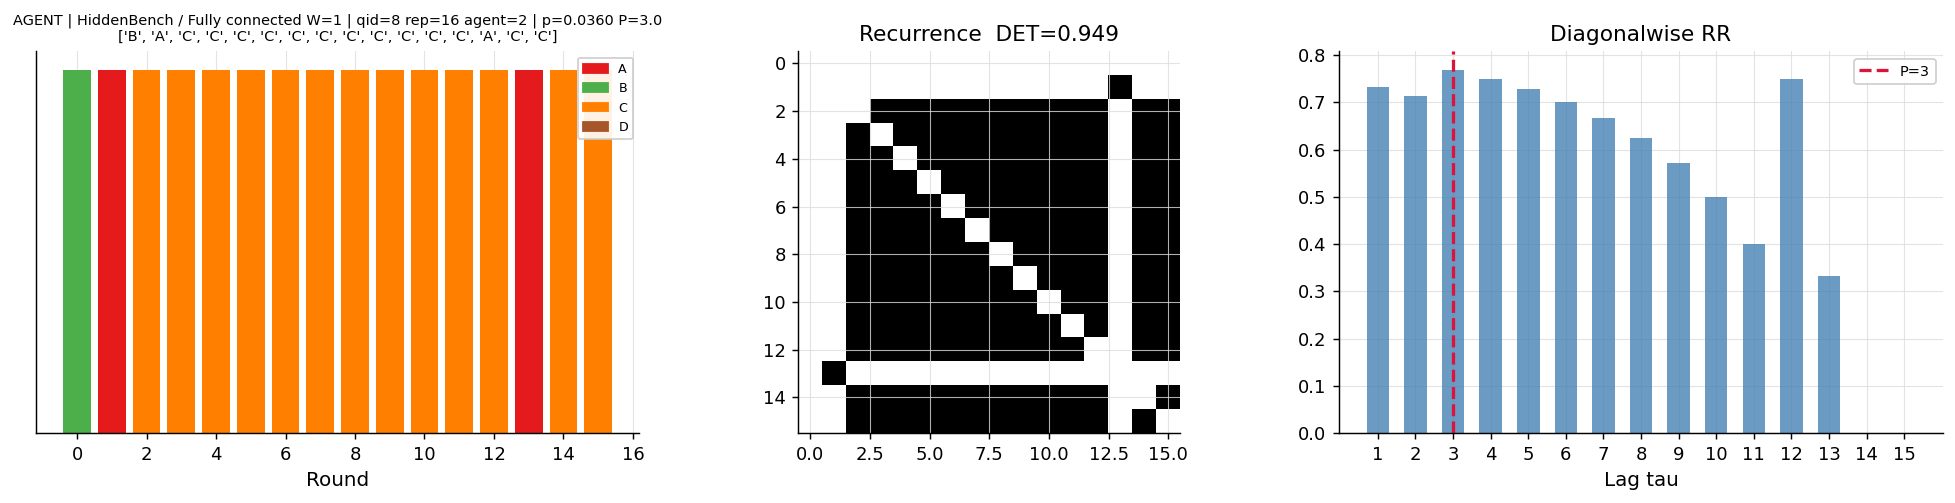

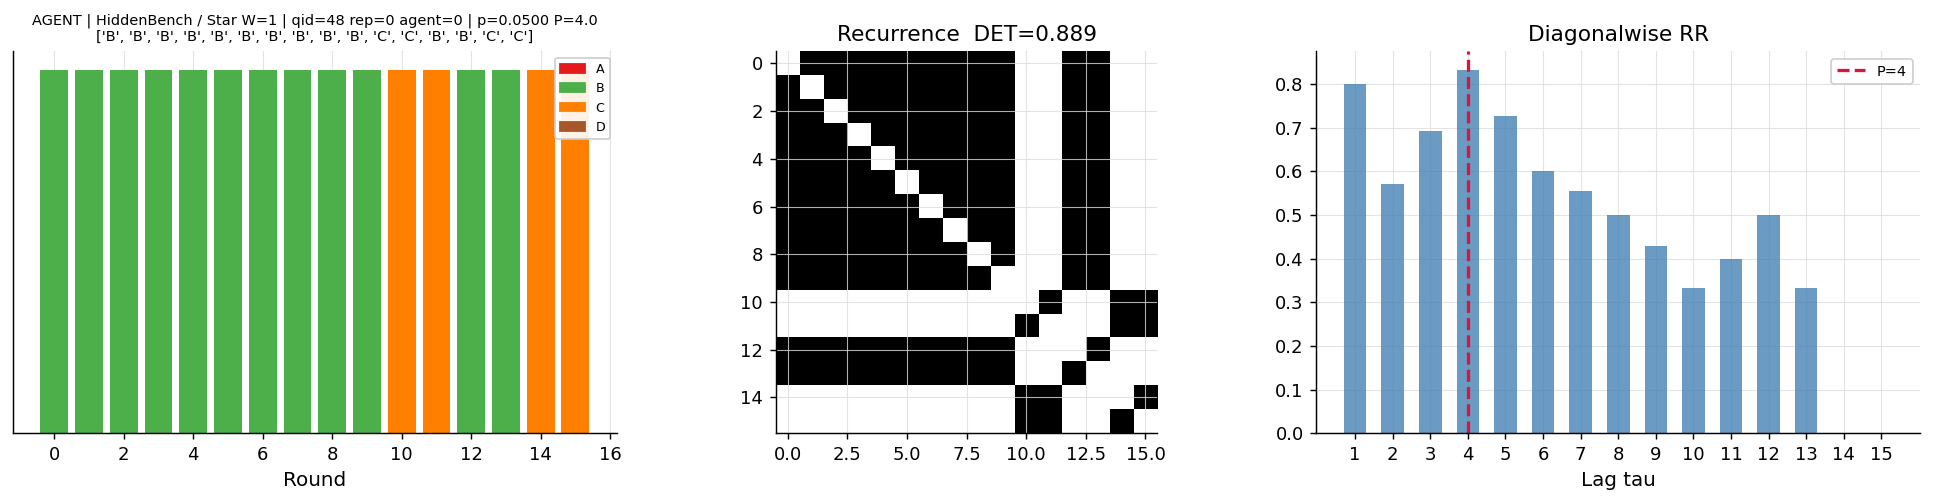

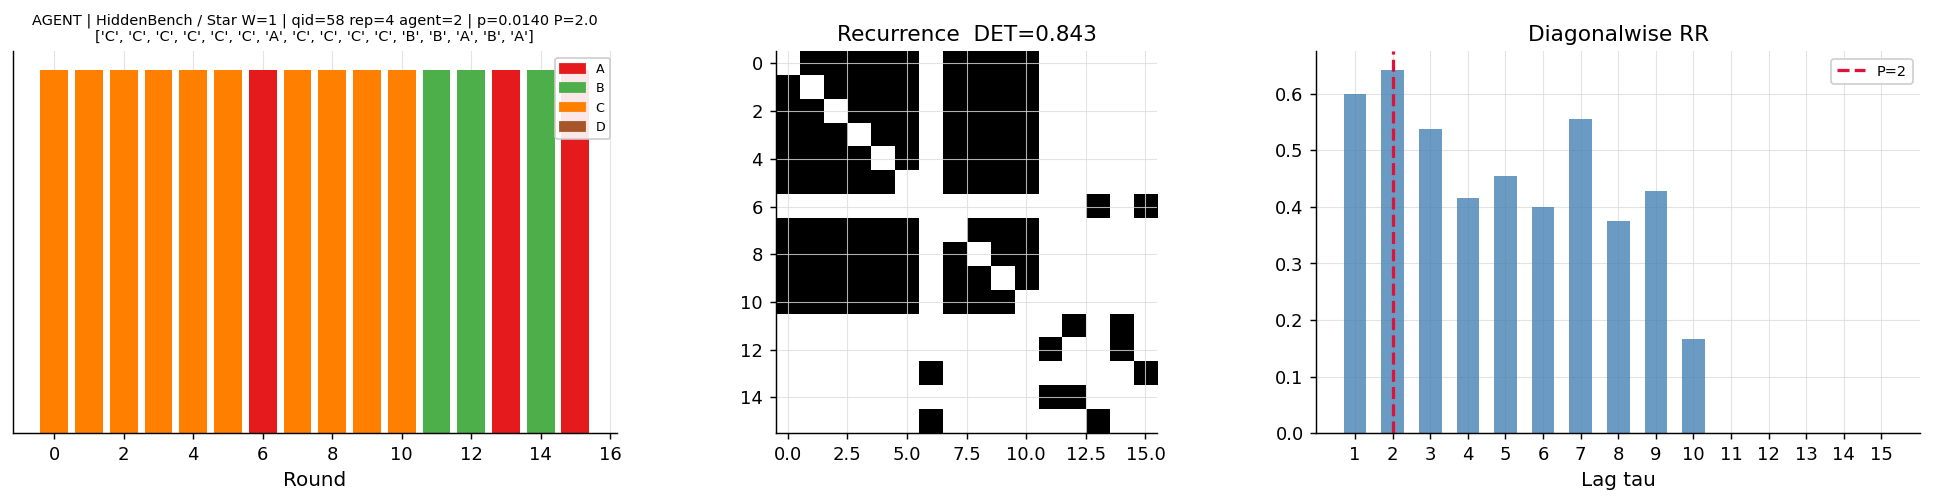

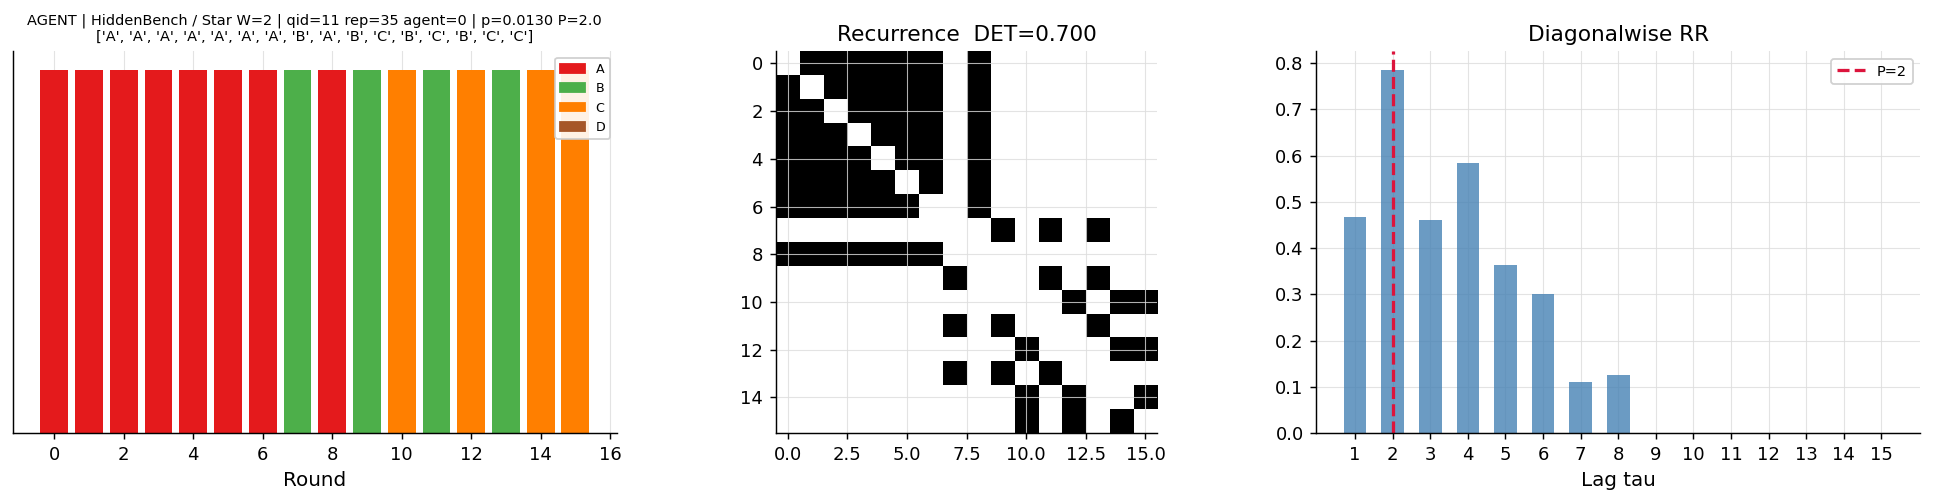

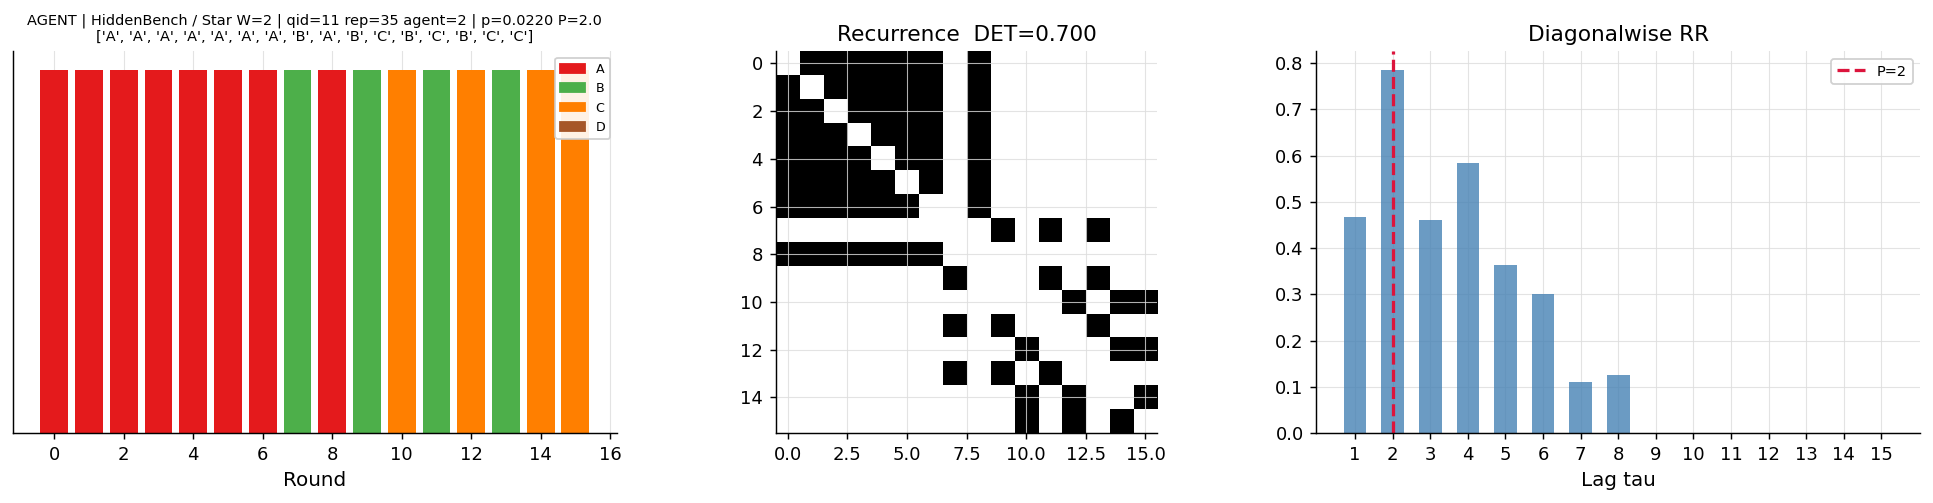

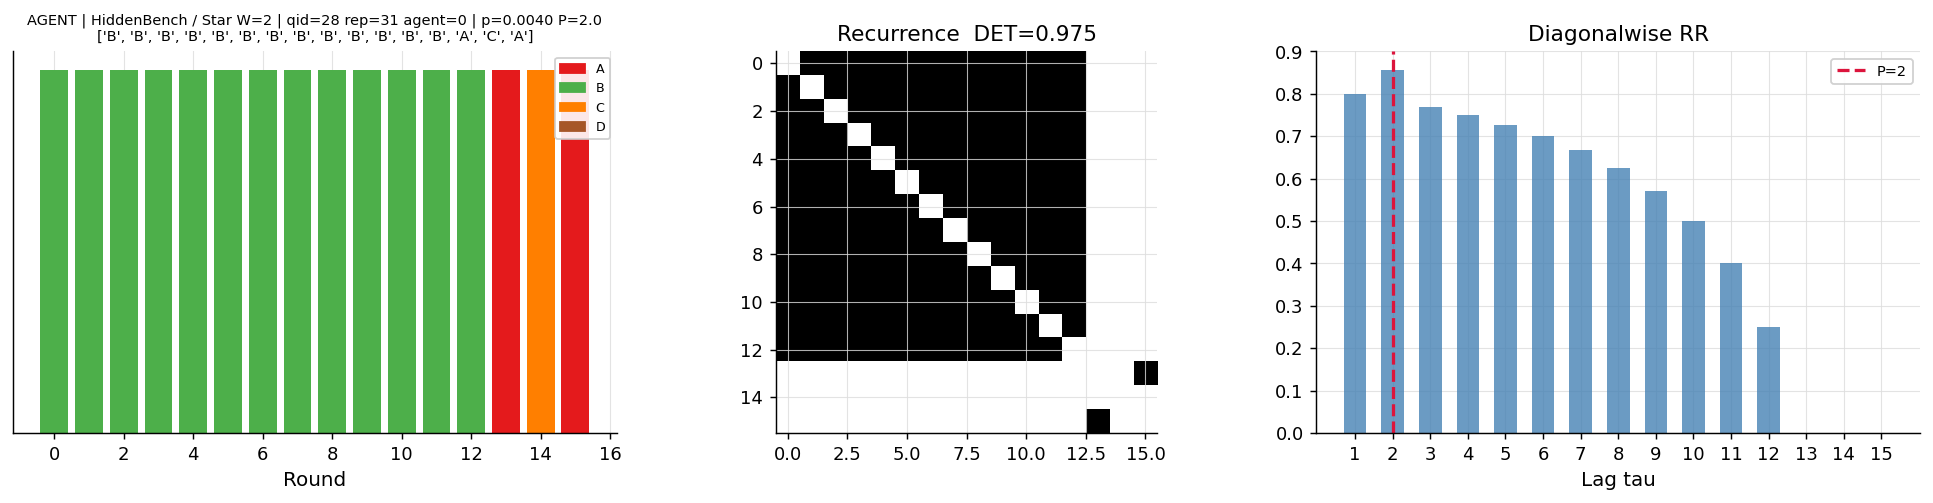

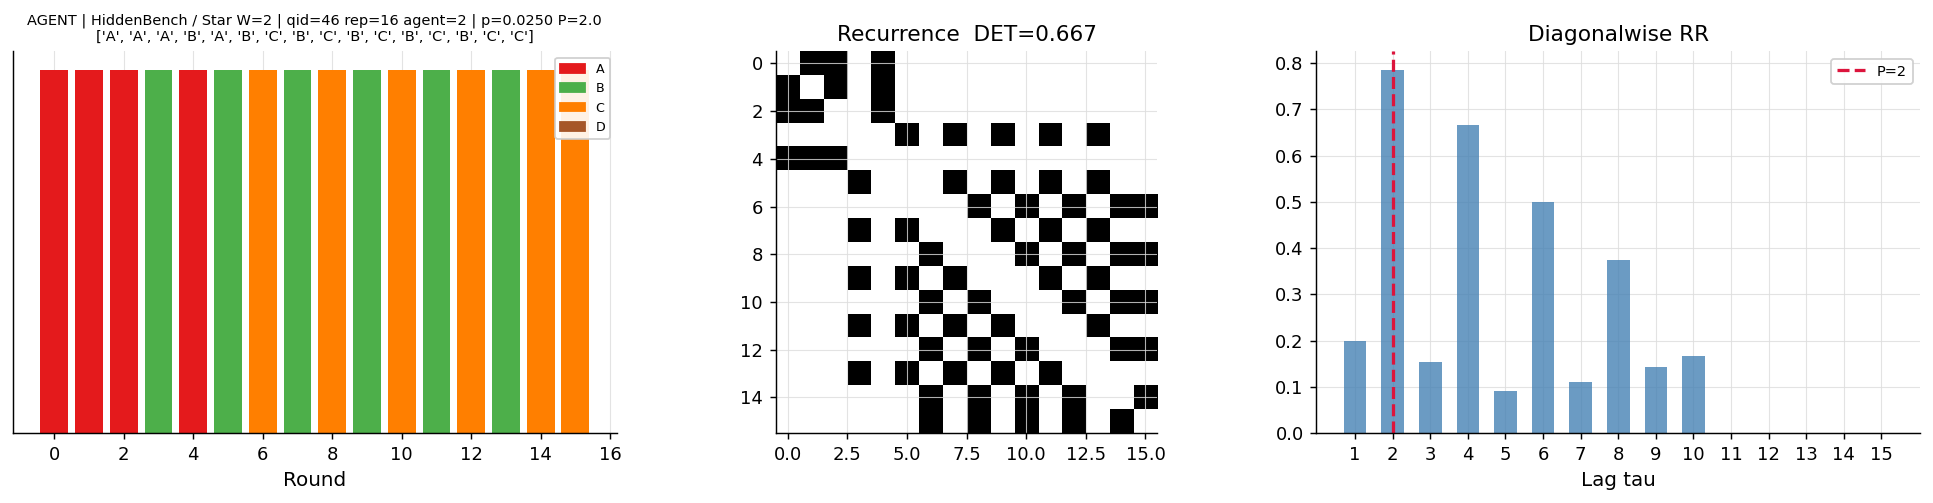

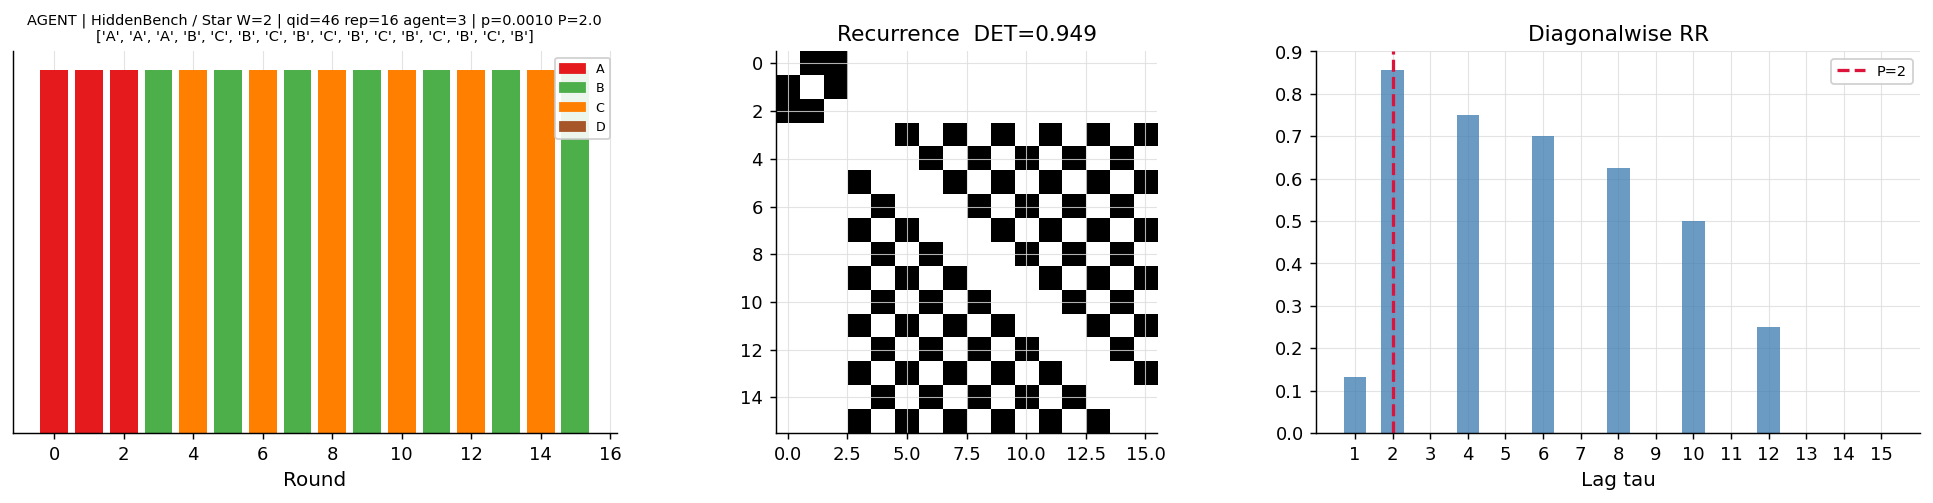

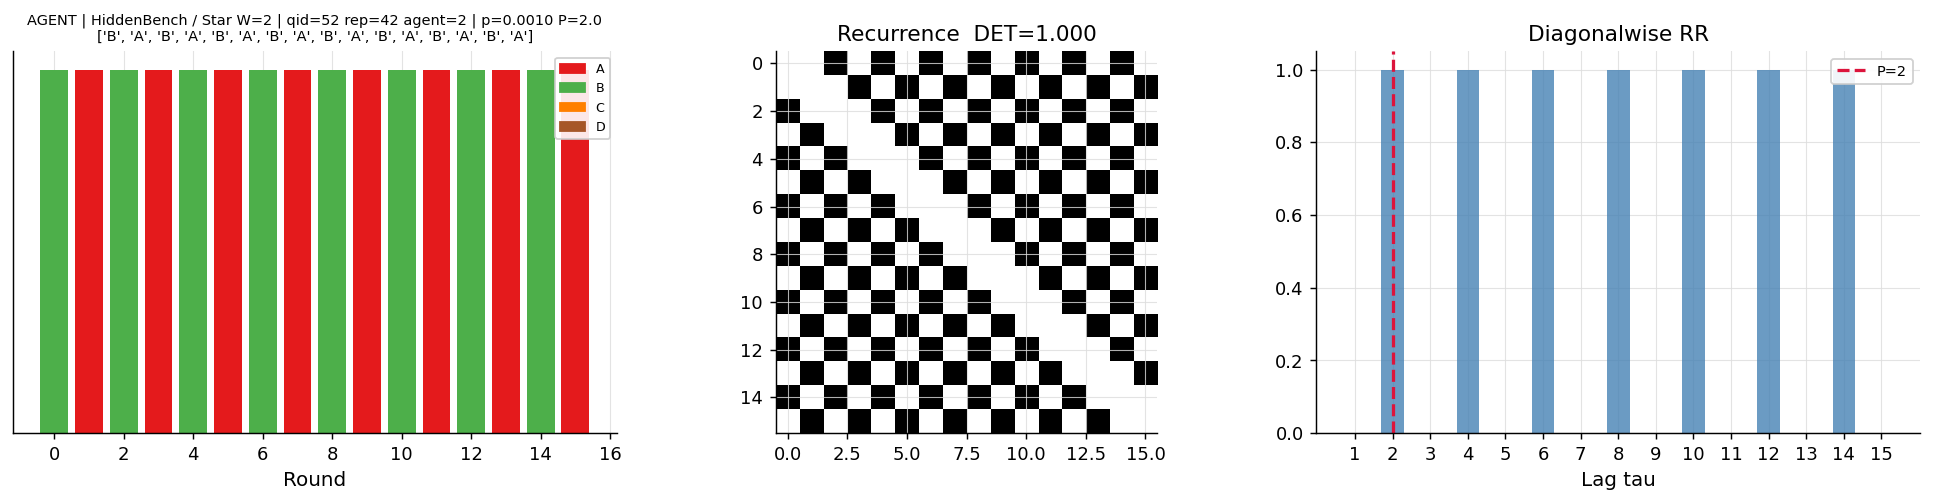

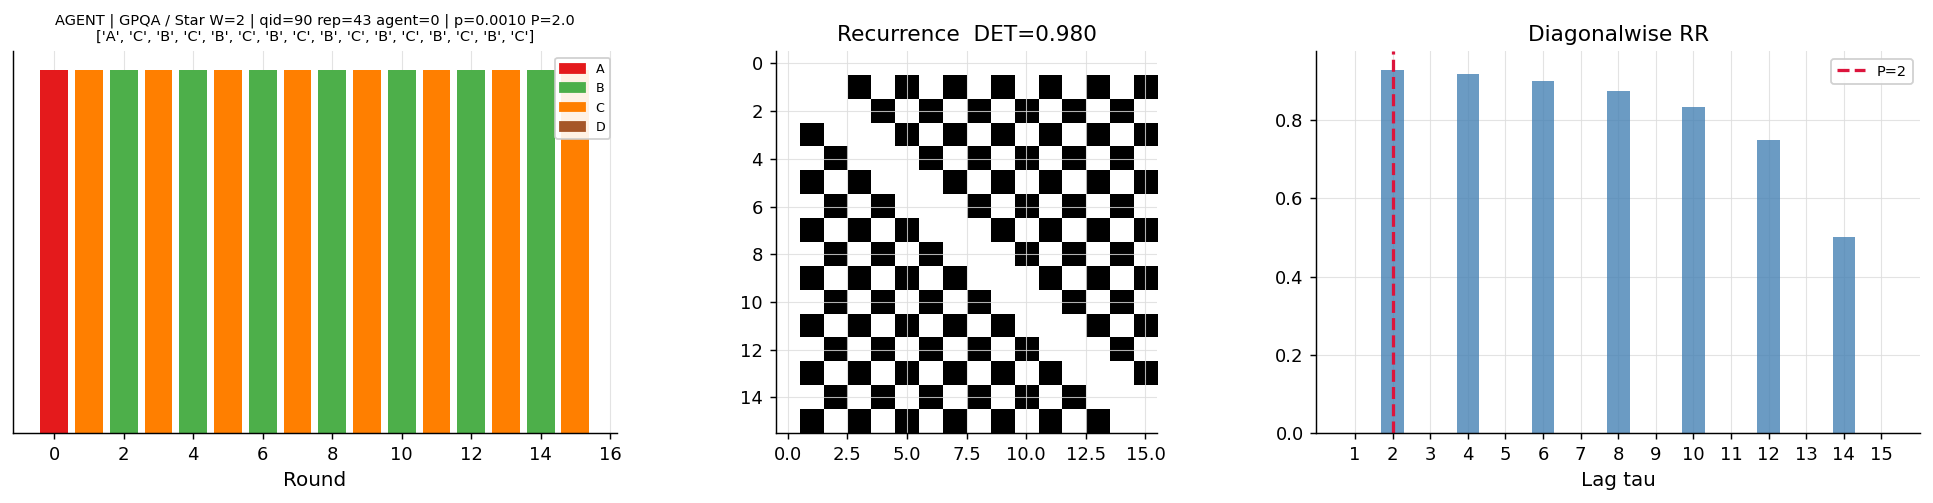

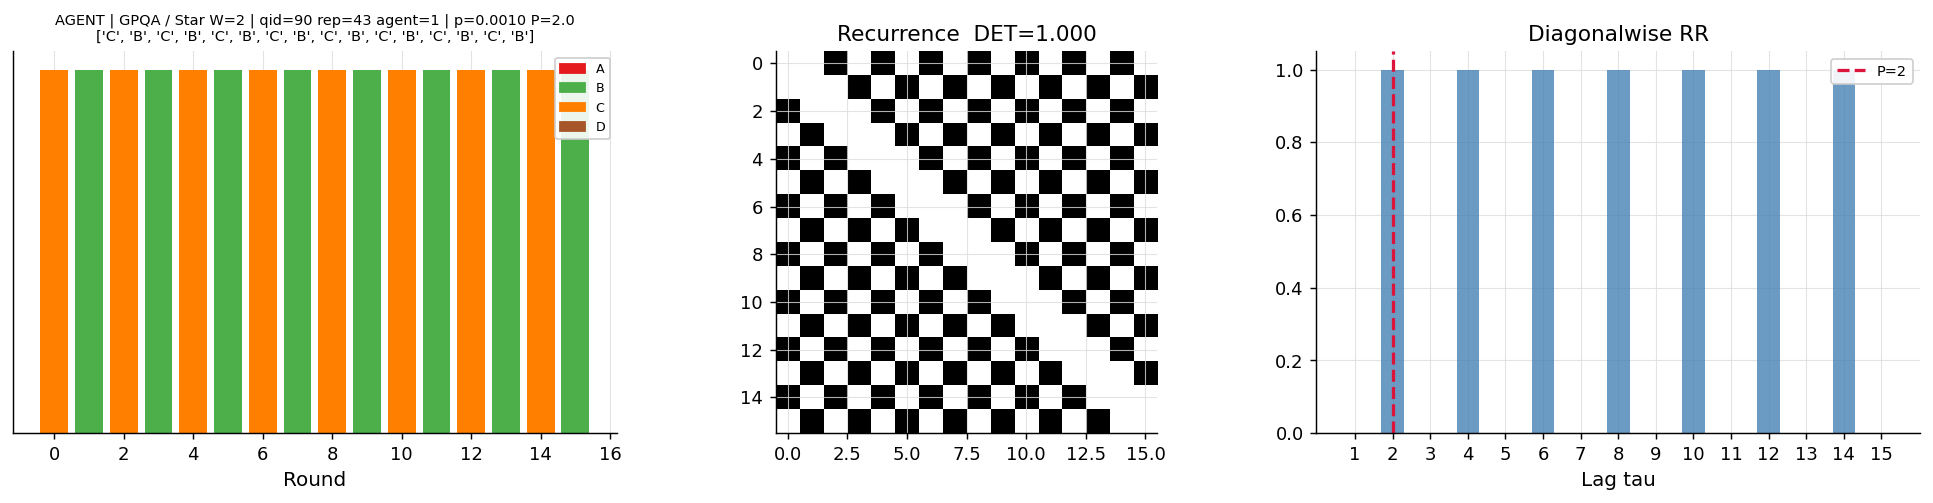

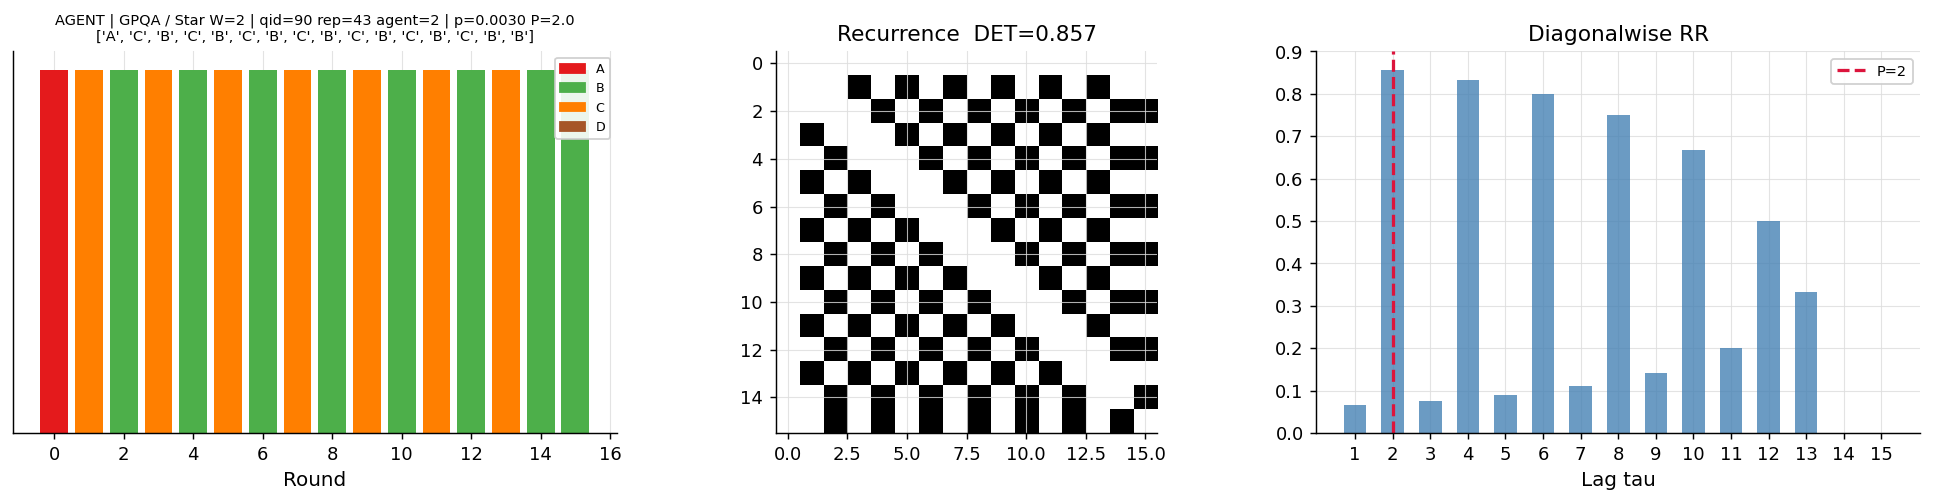

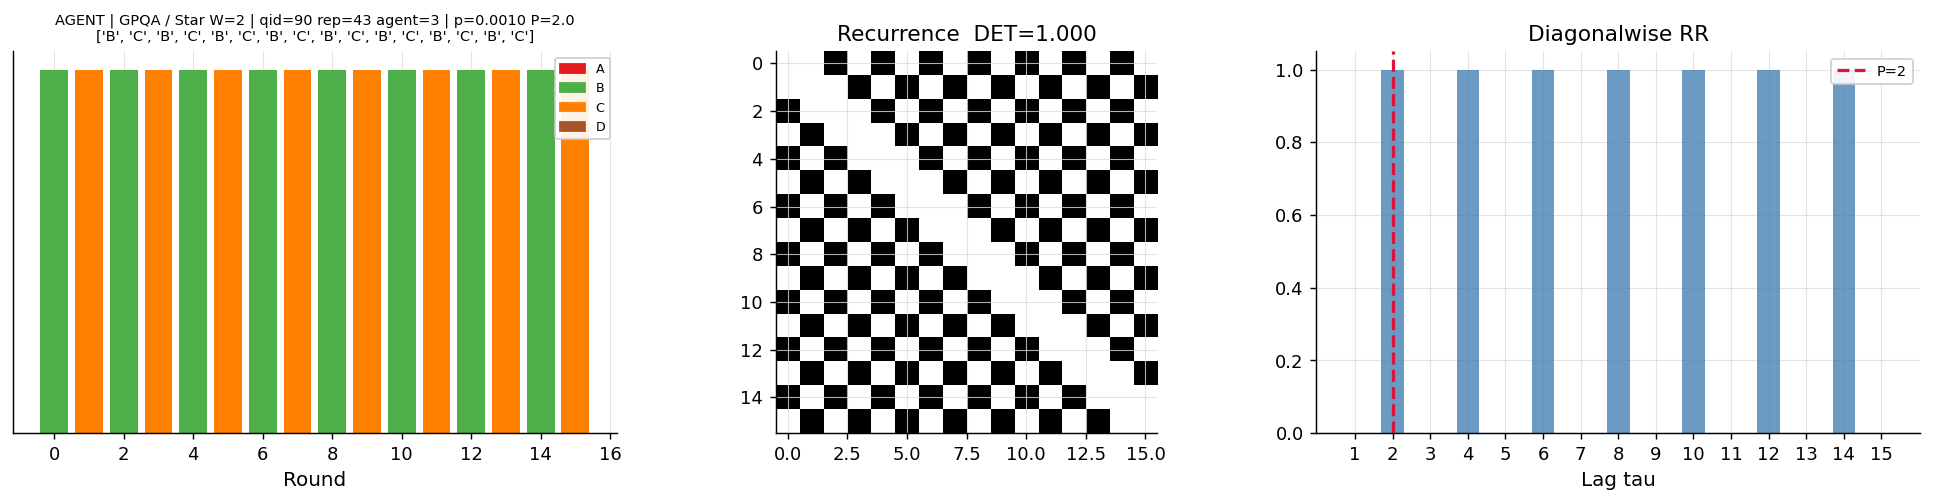

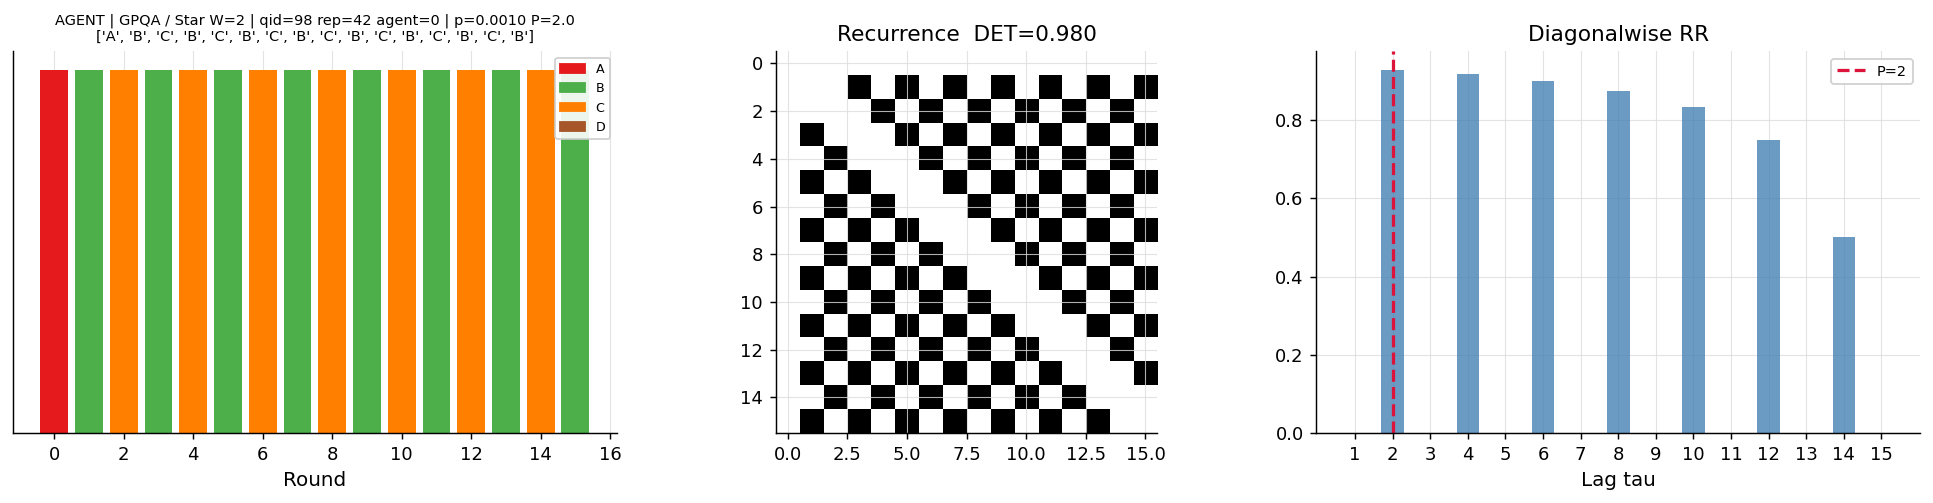

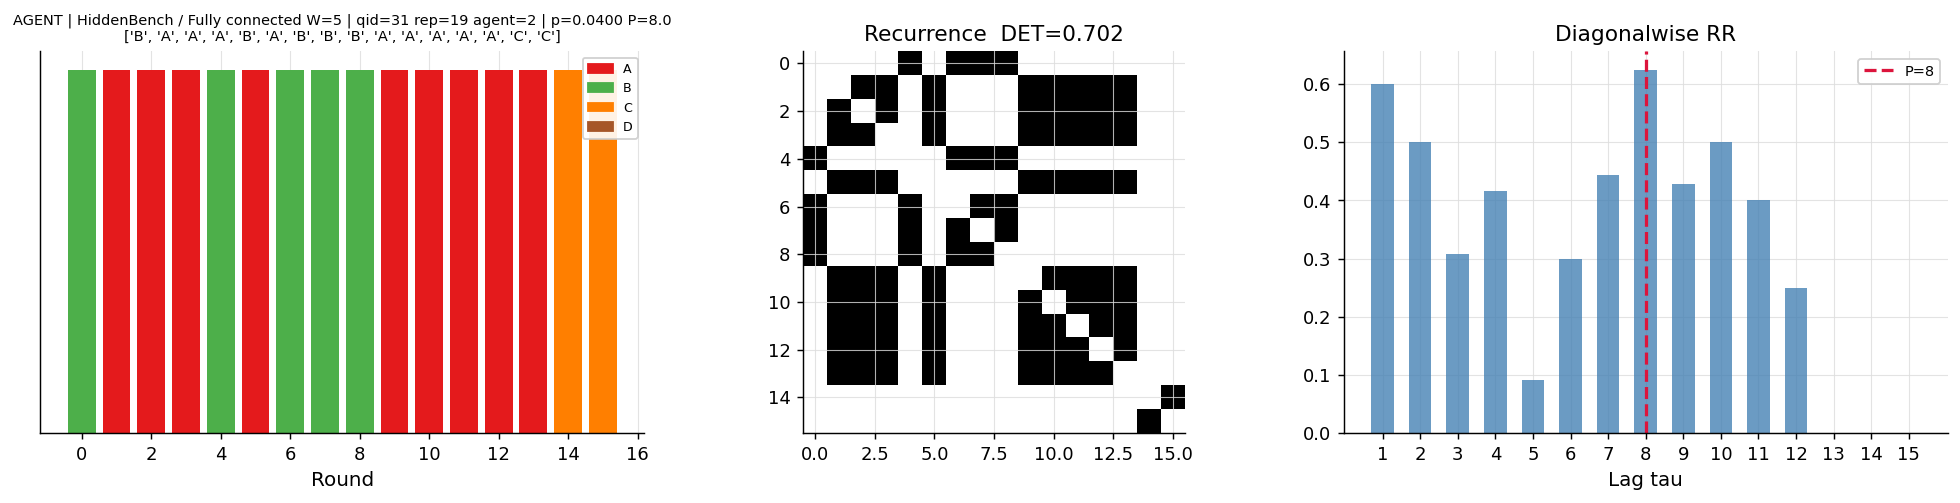

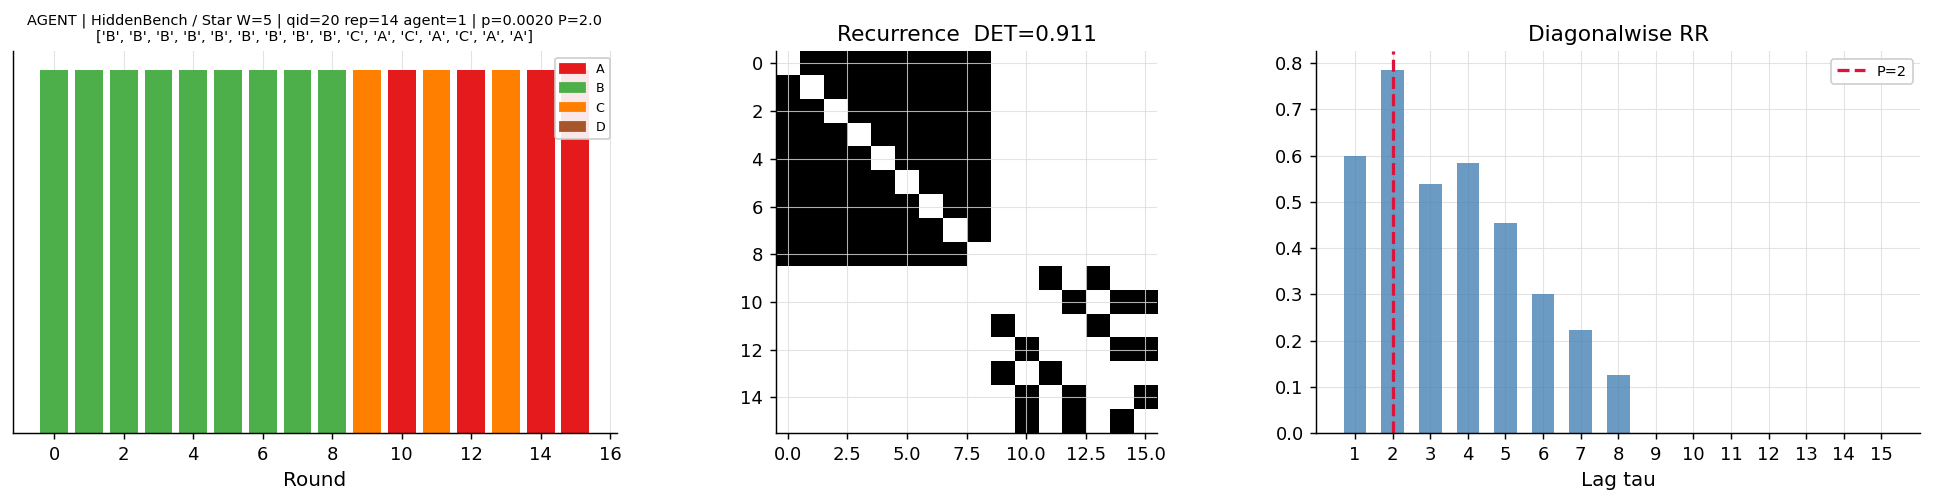

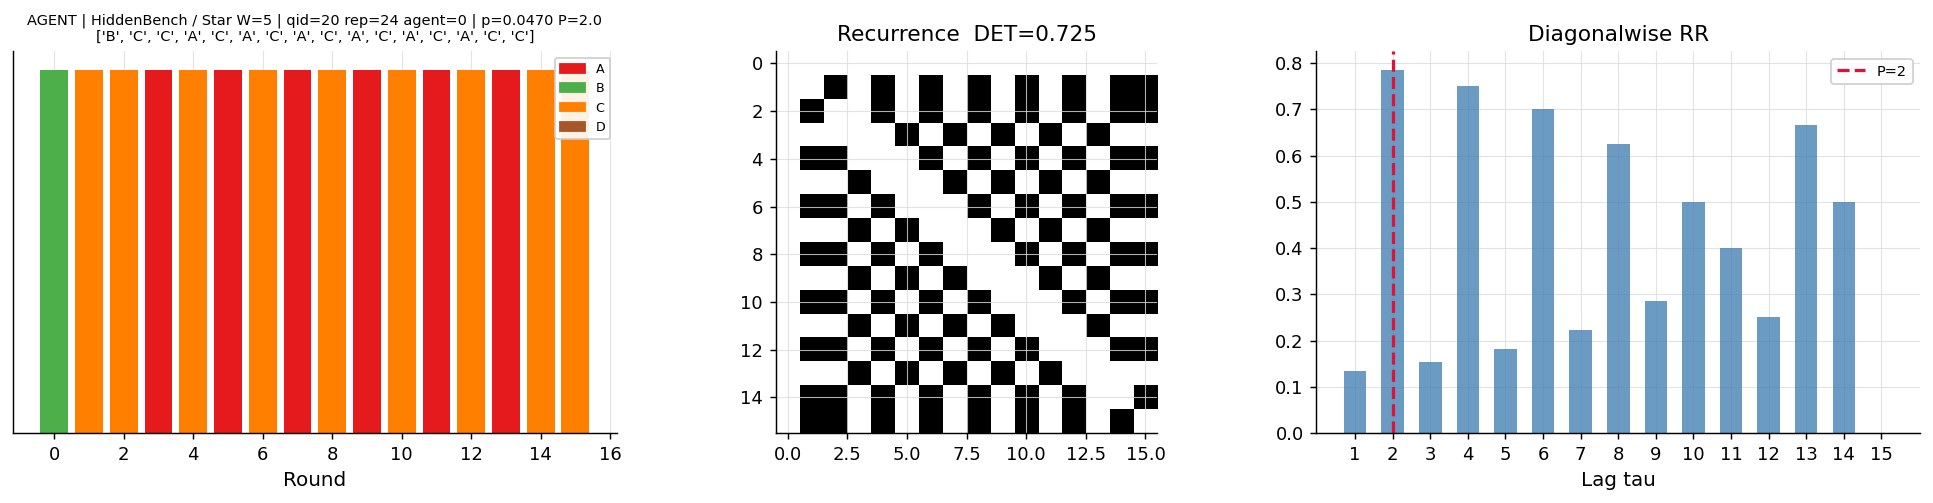

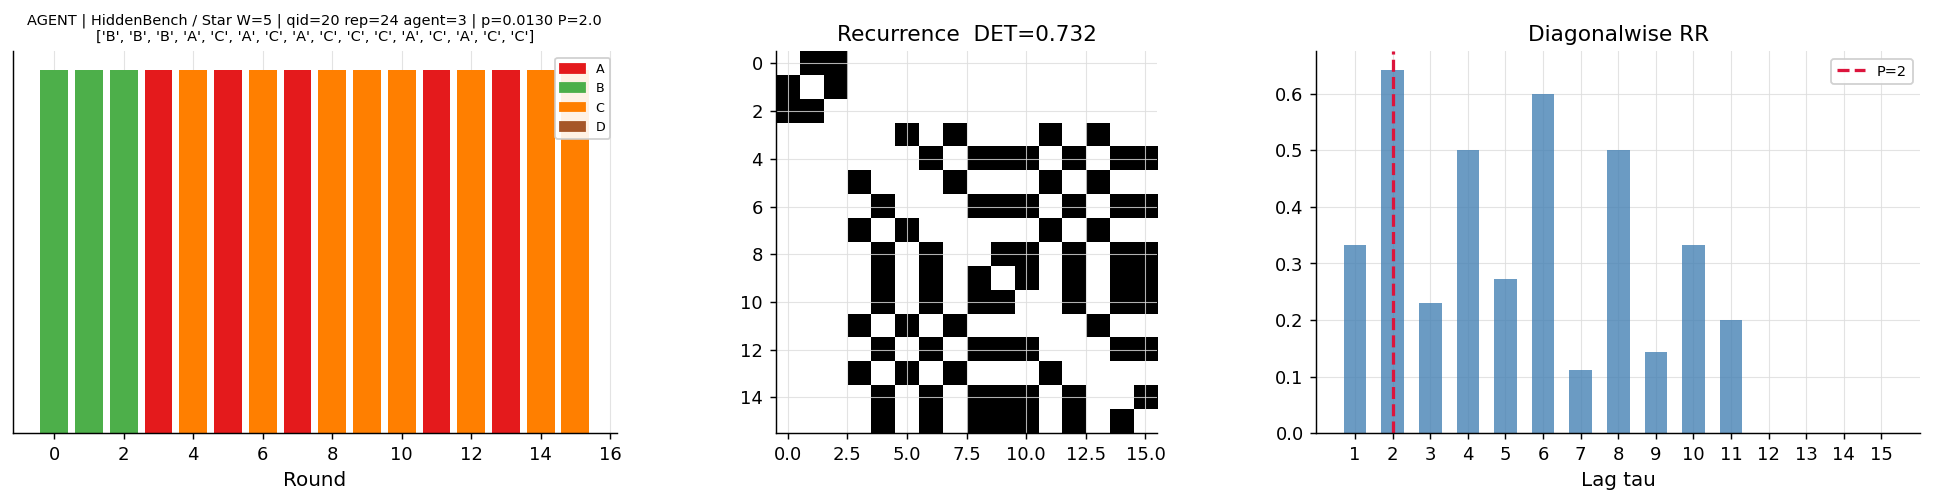

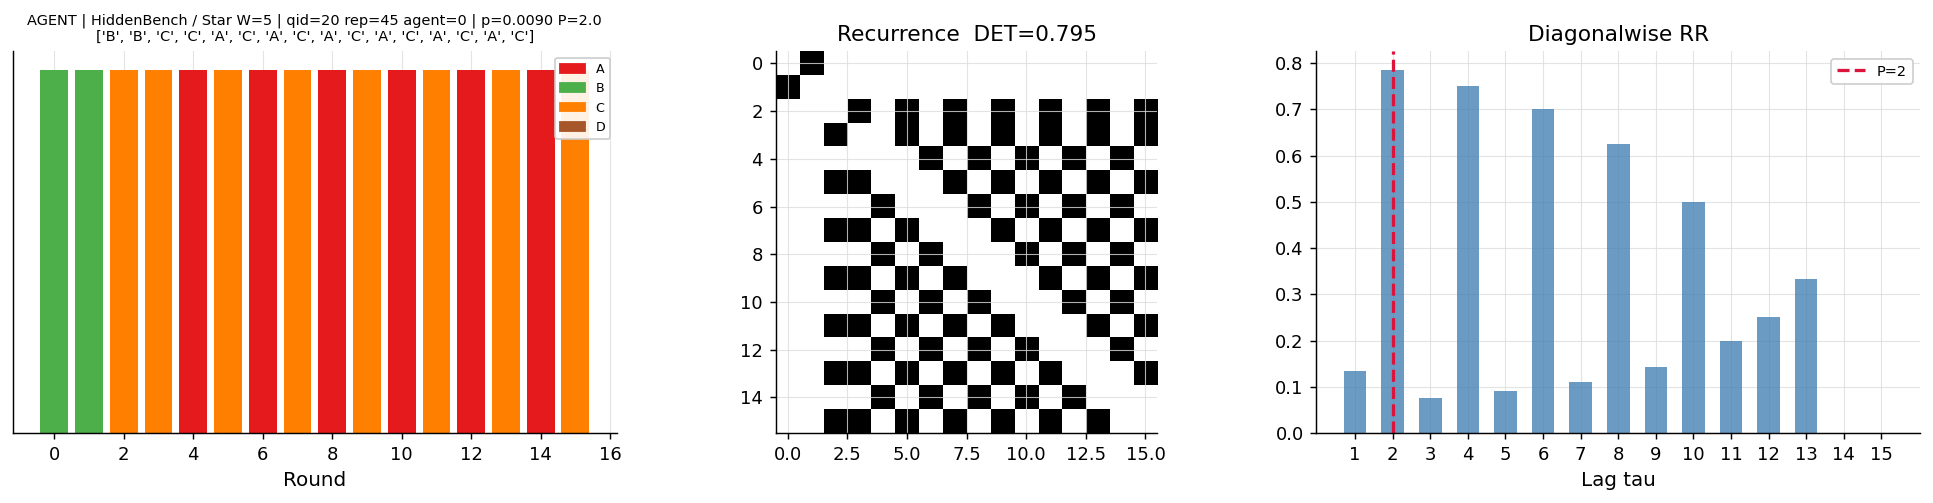

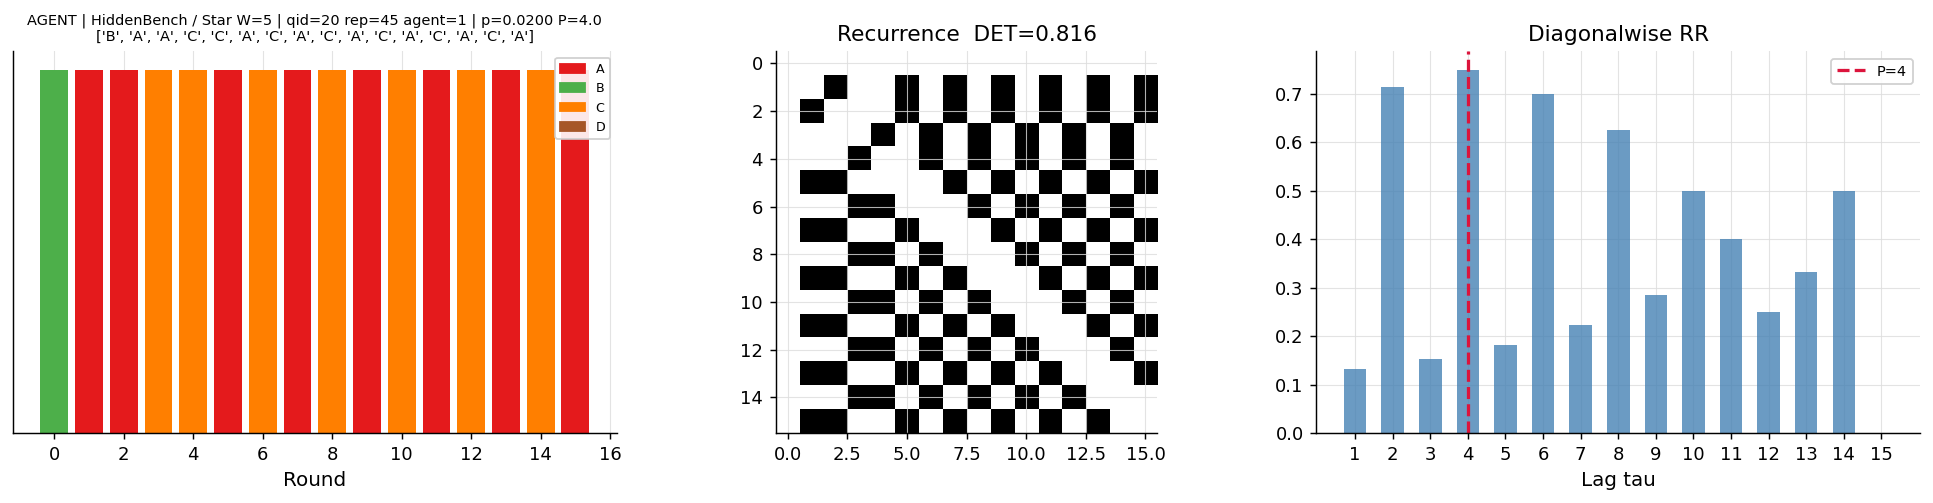

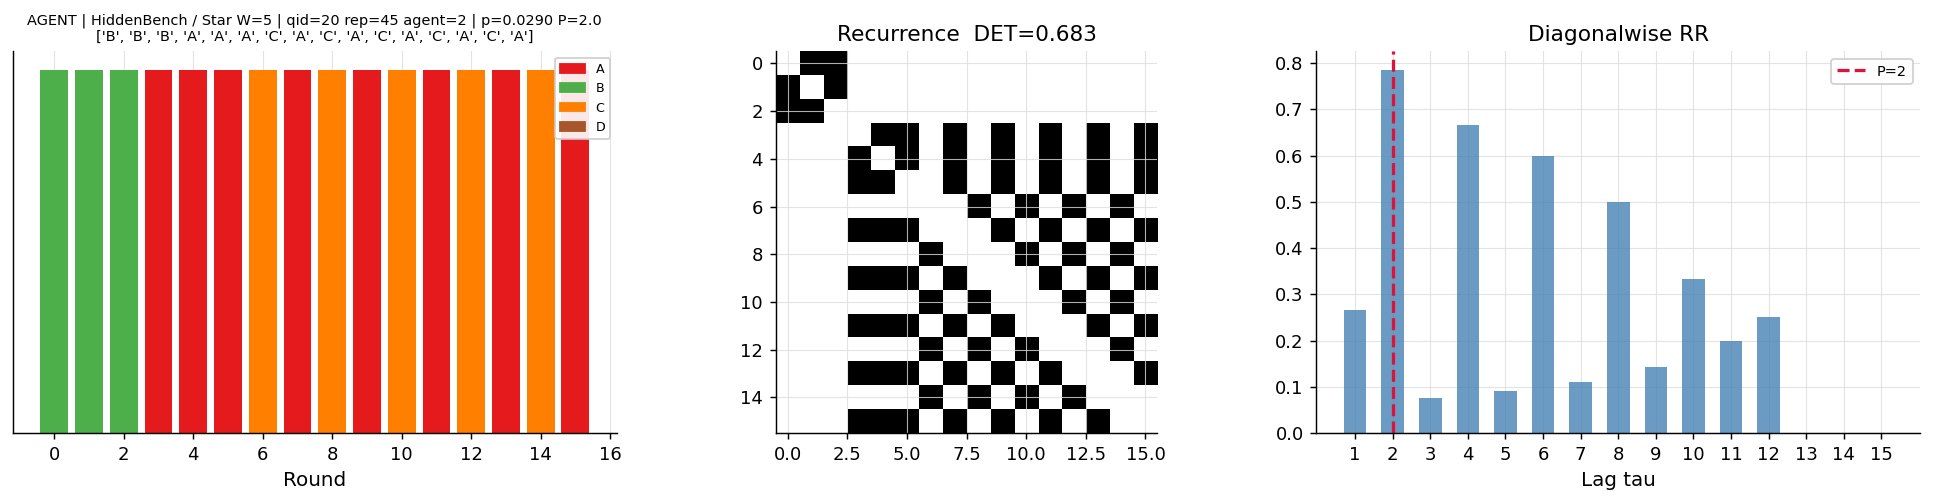

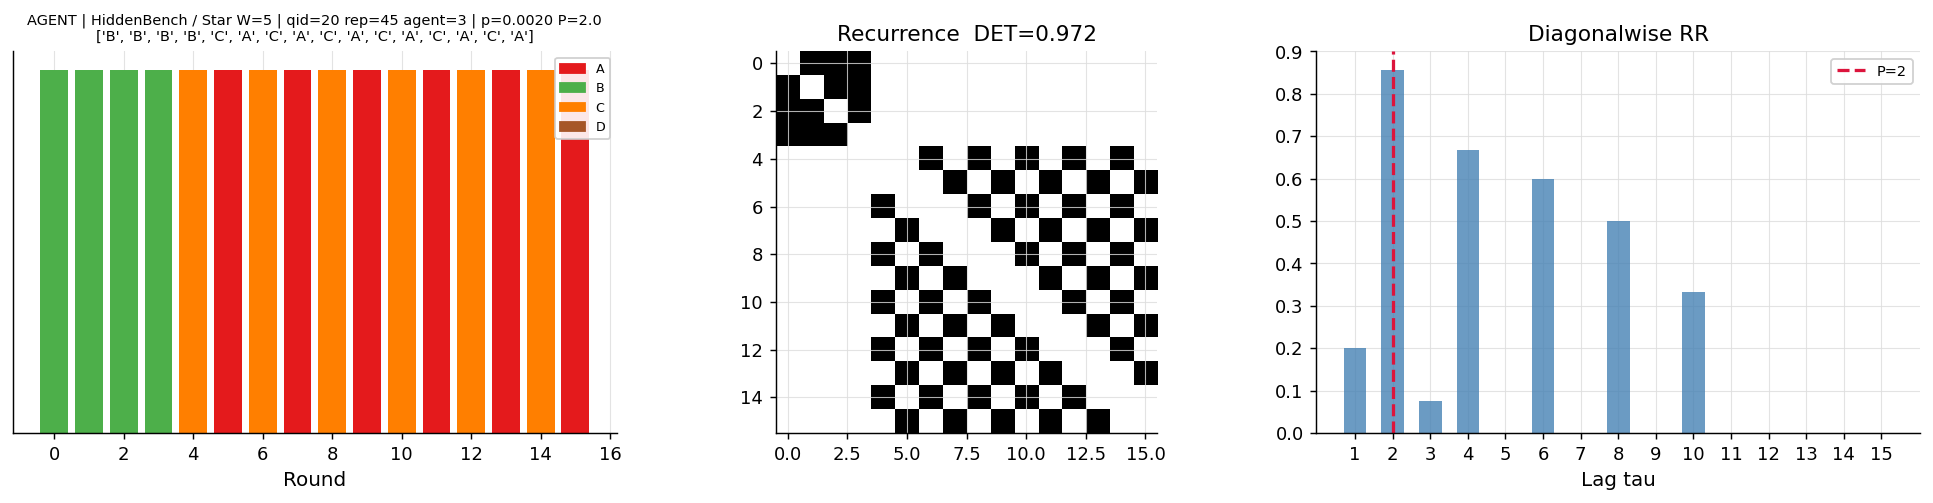

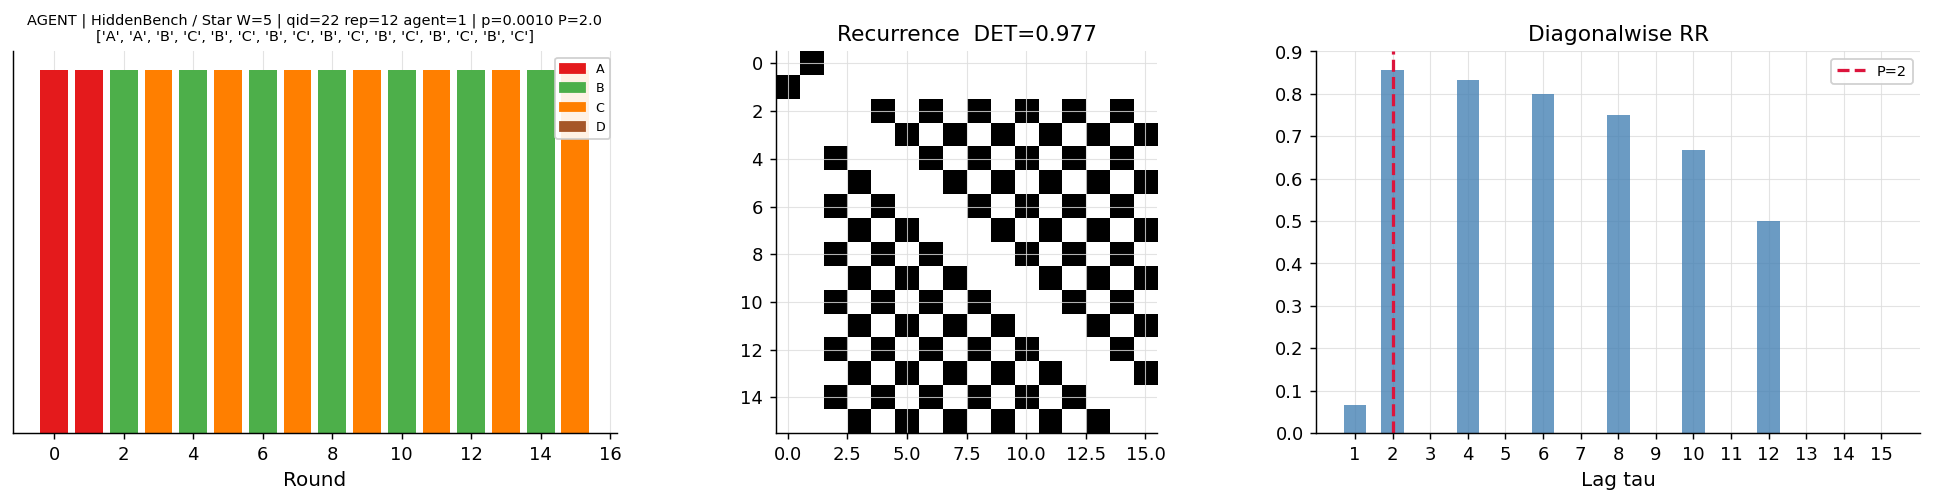

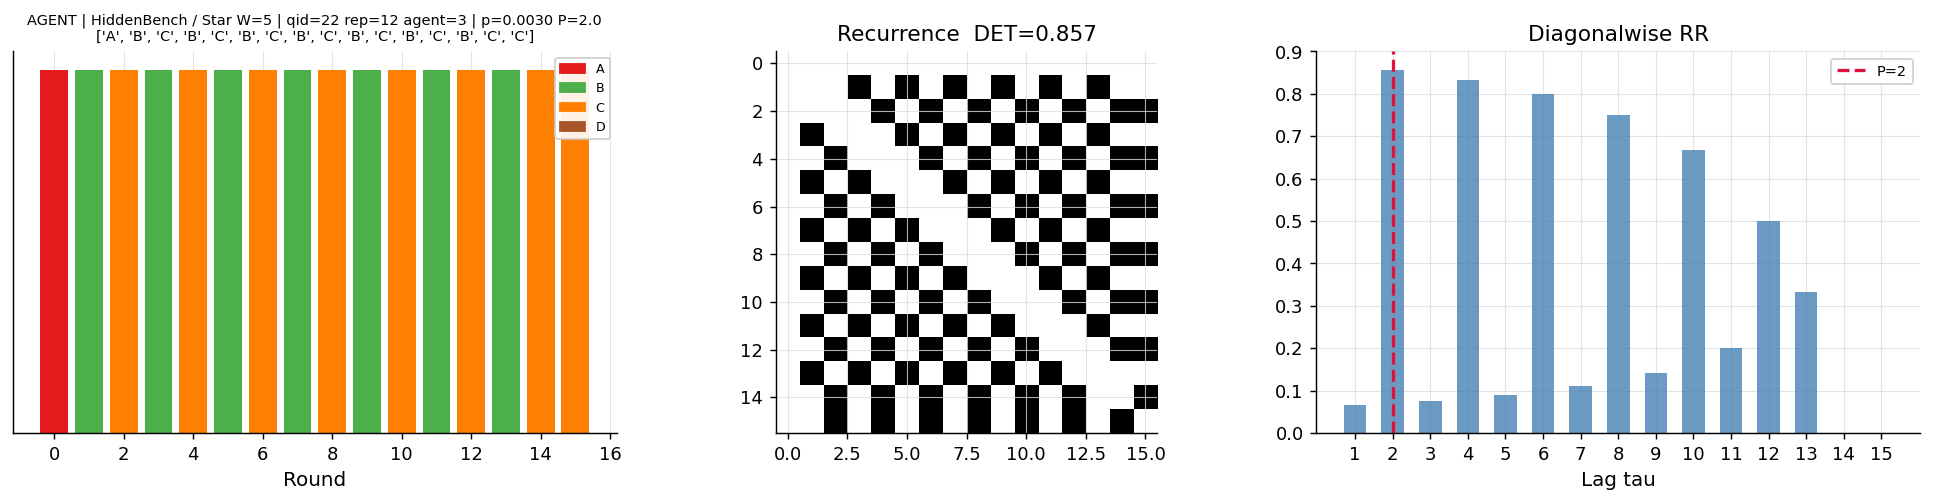

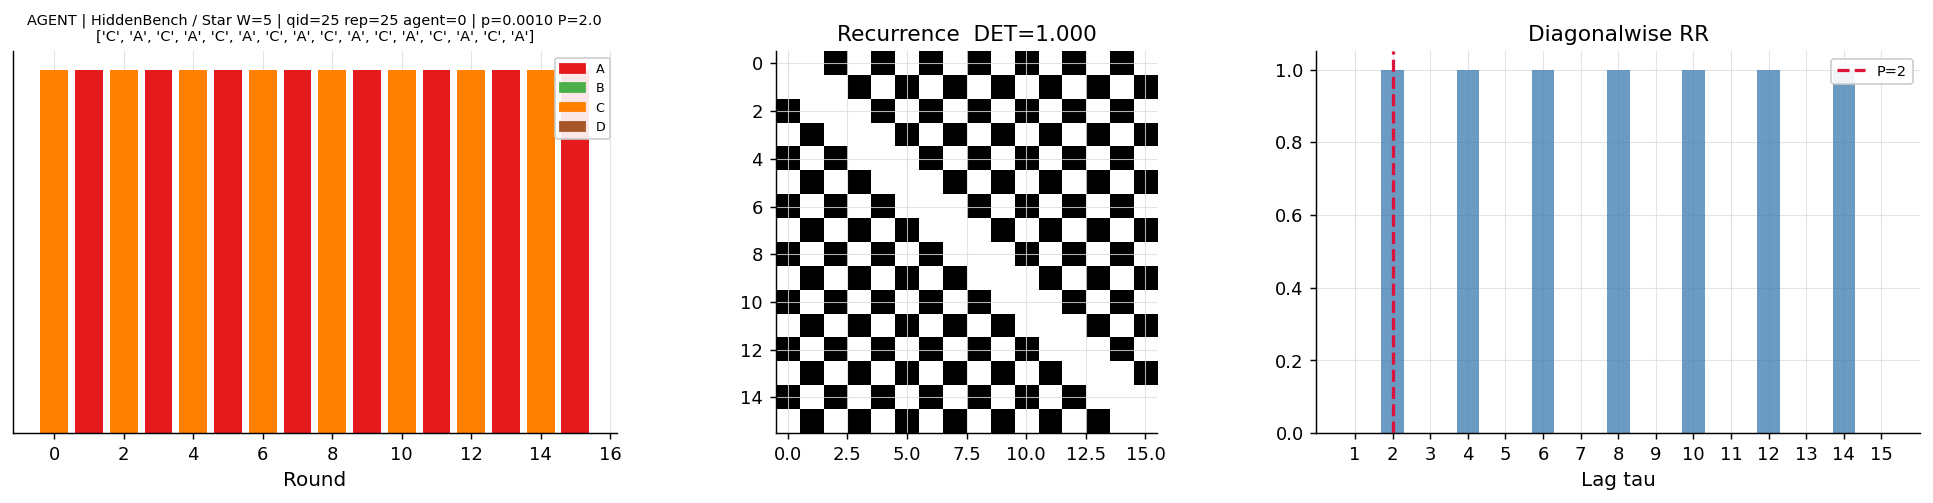

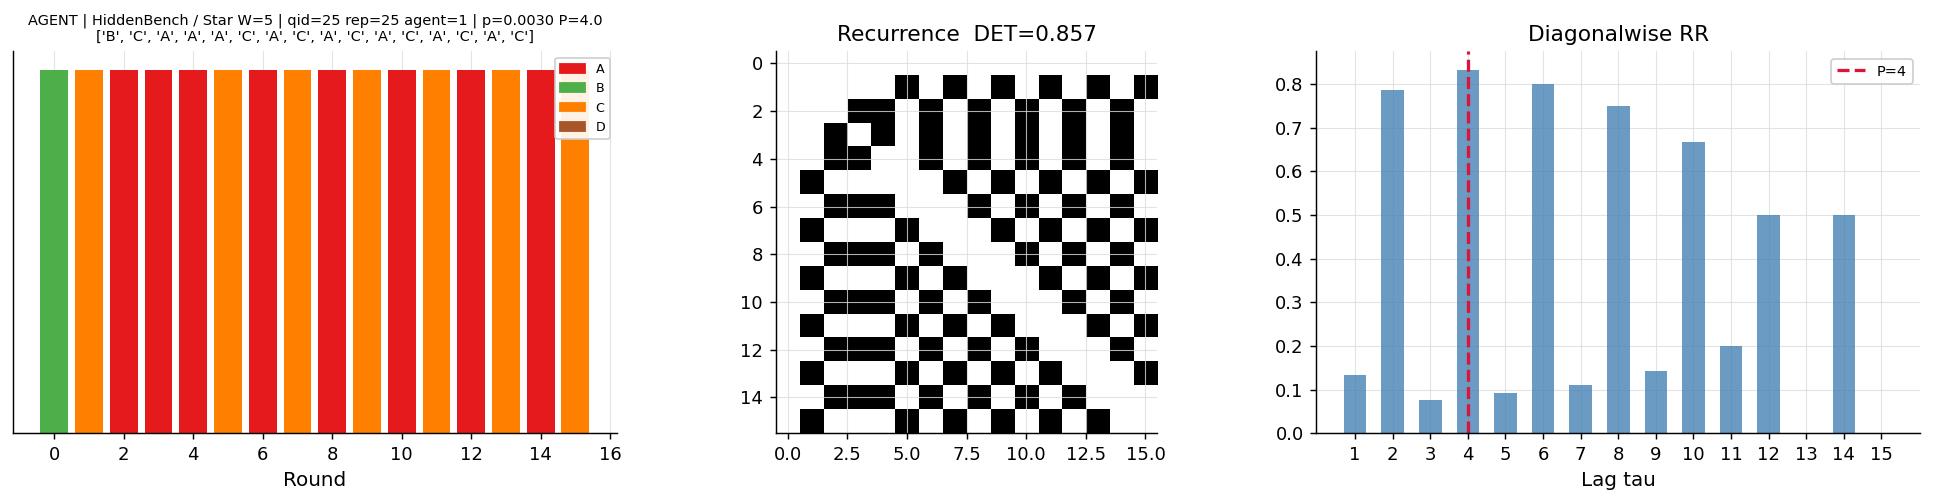

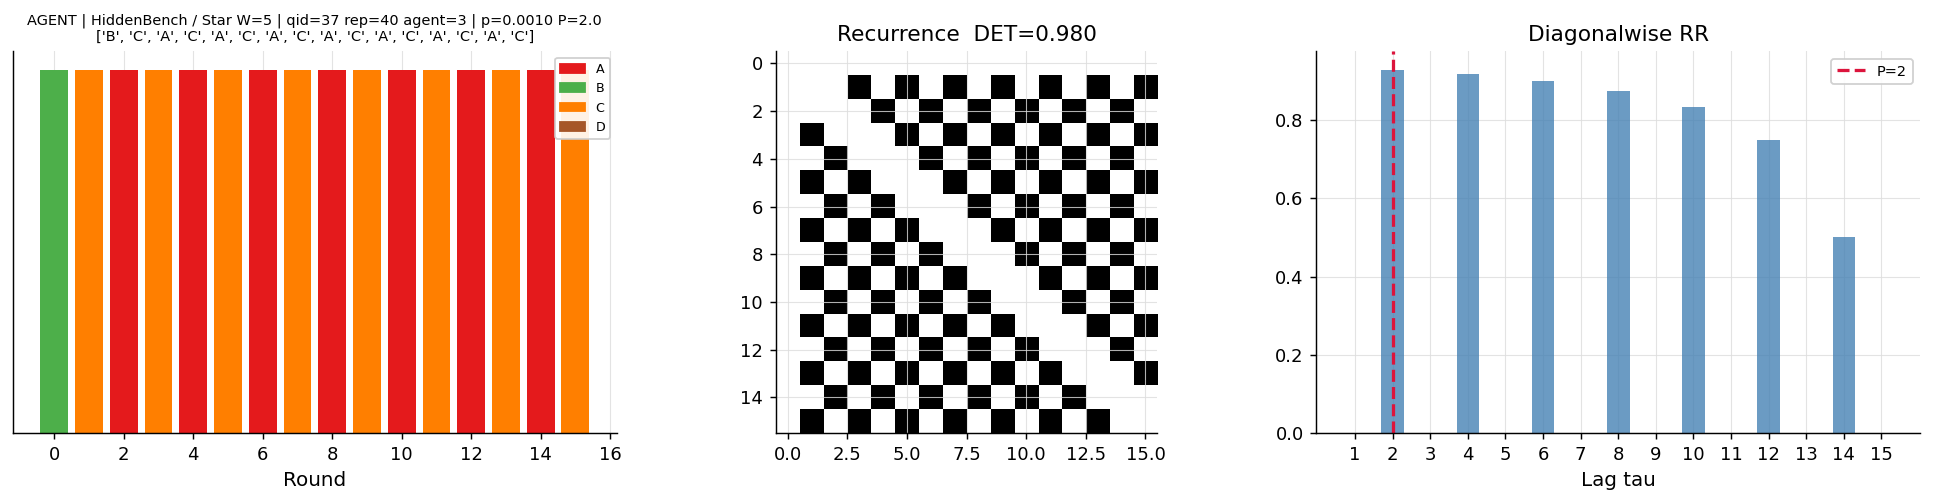

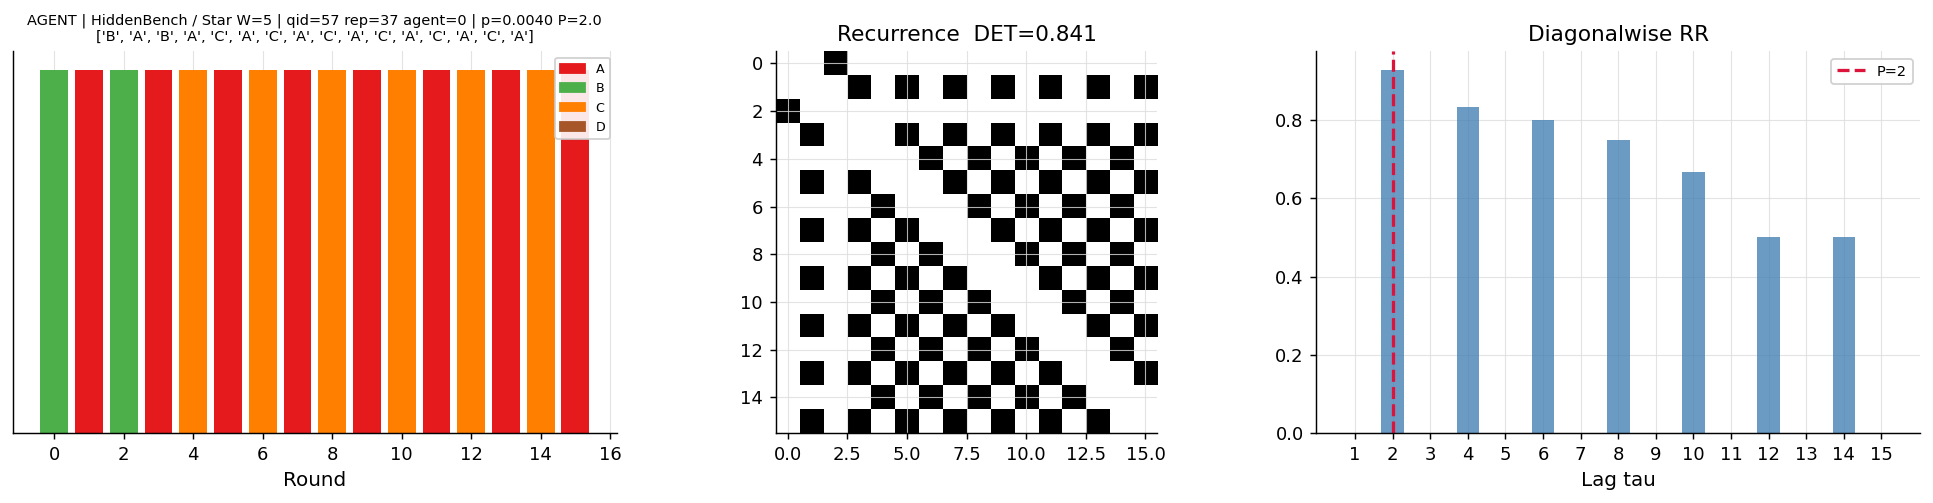

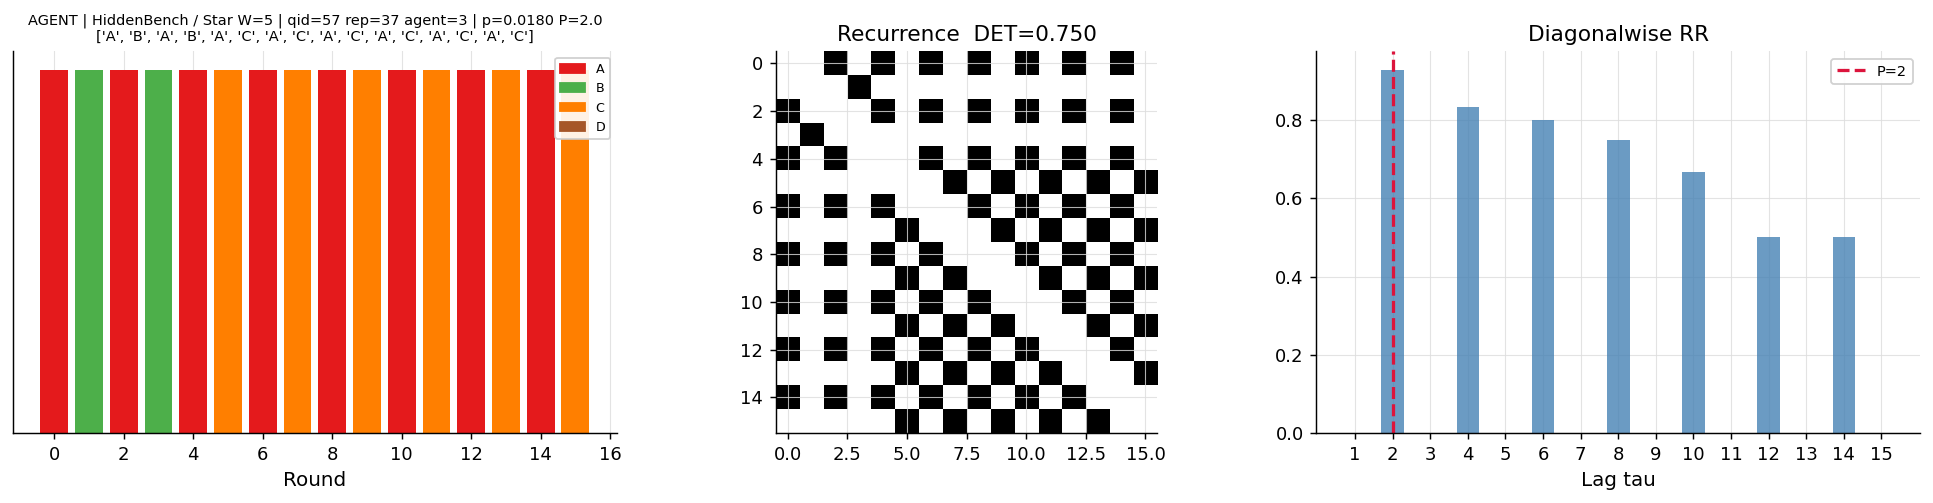

SYSTEM-level flagged cases (23):


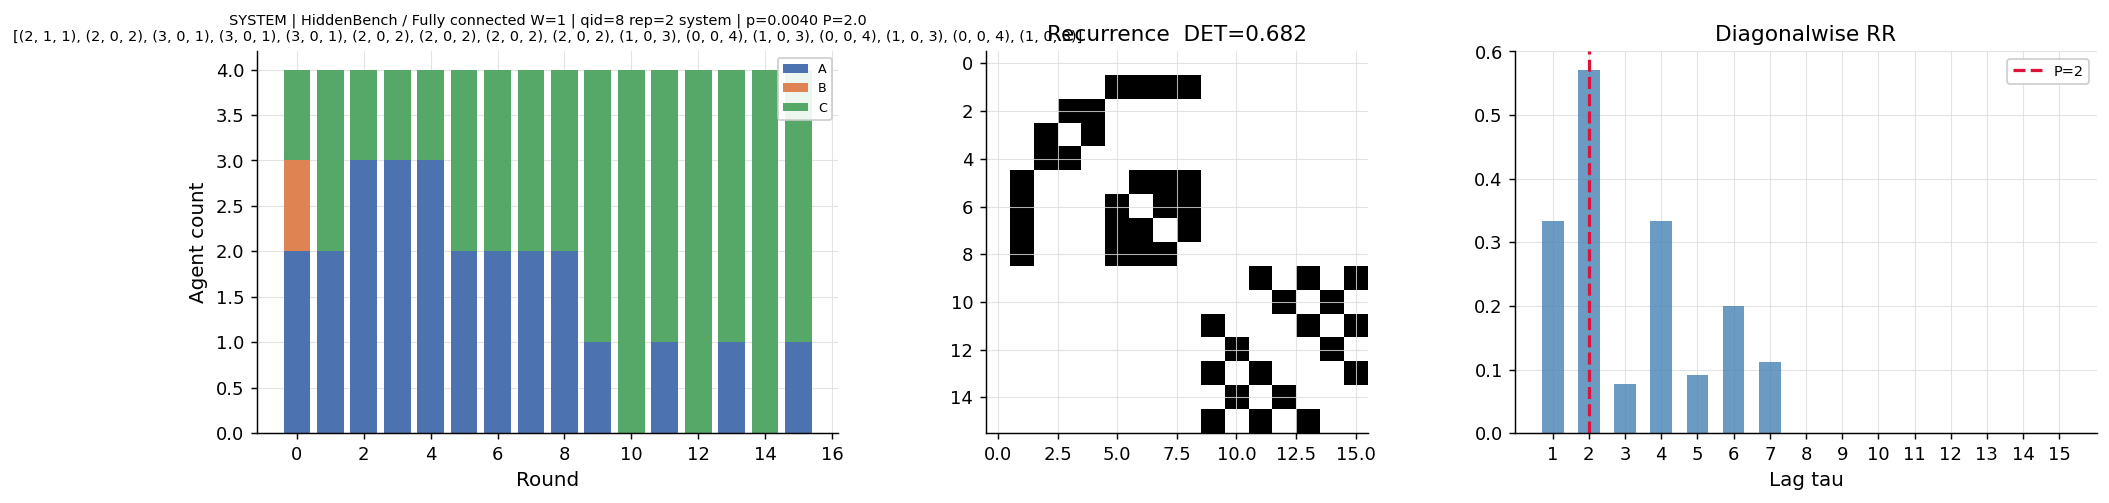

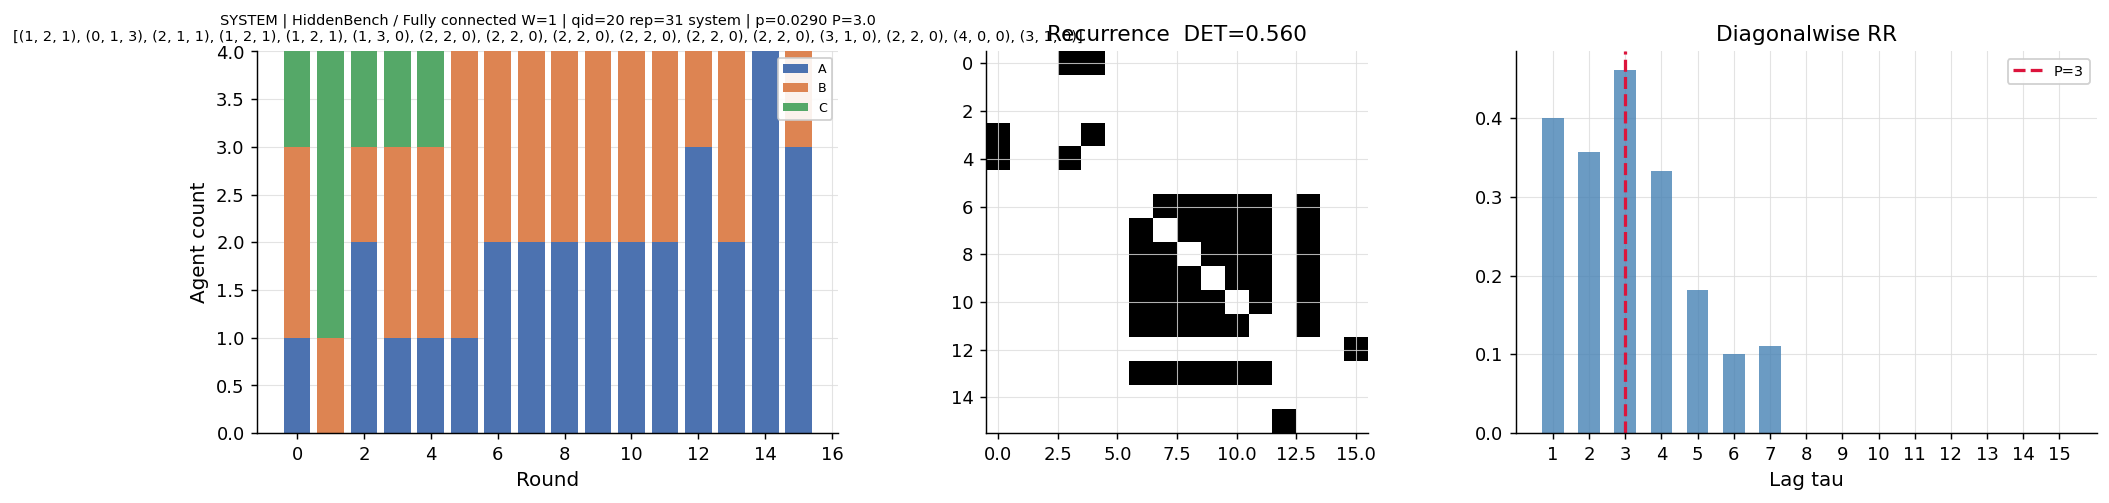

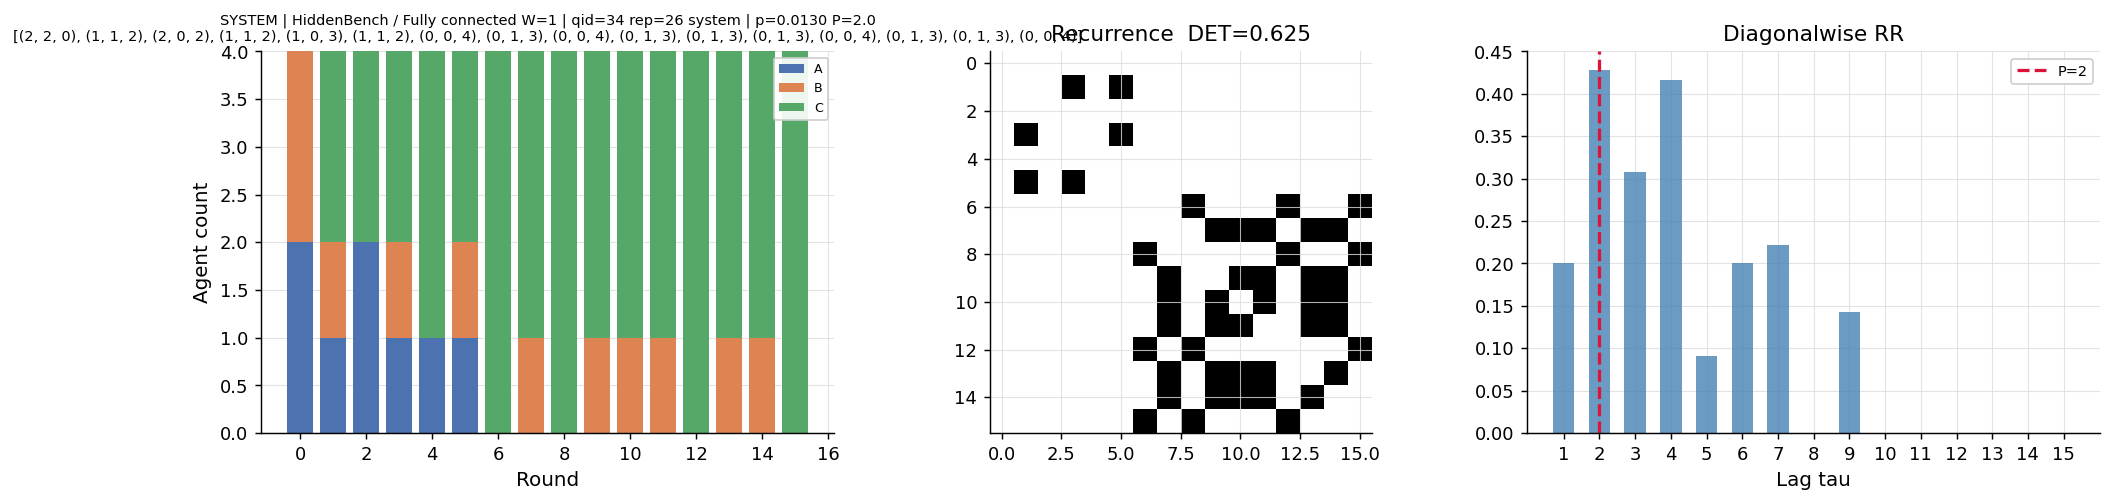

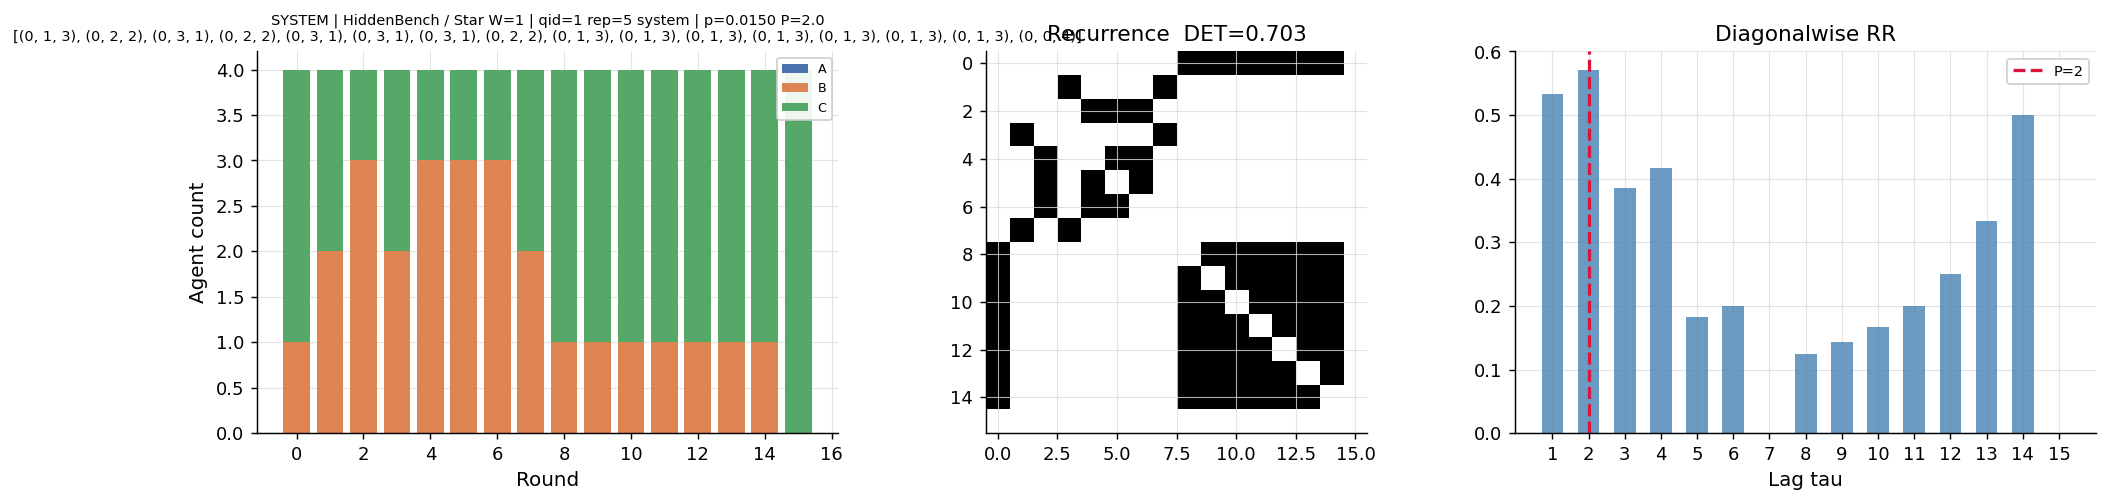

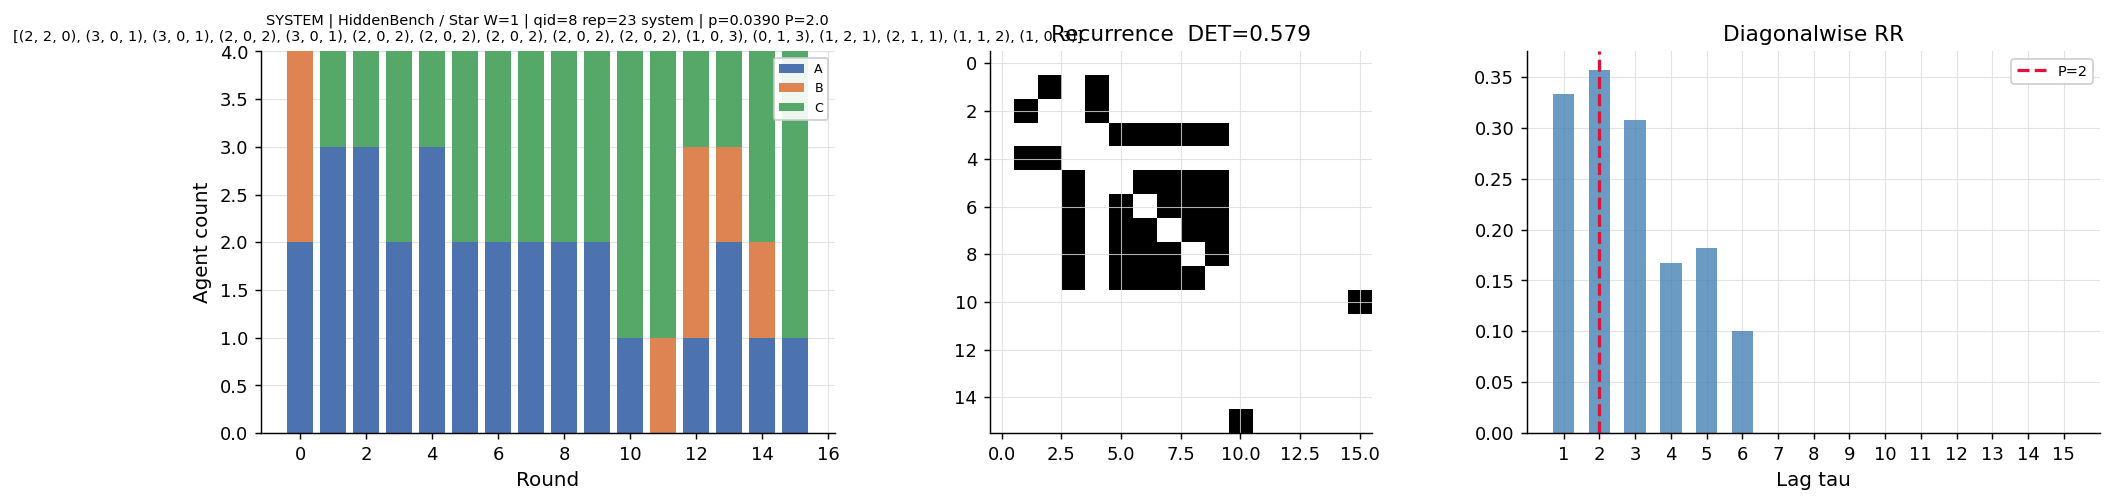

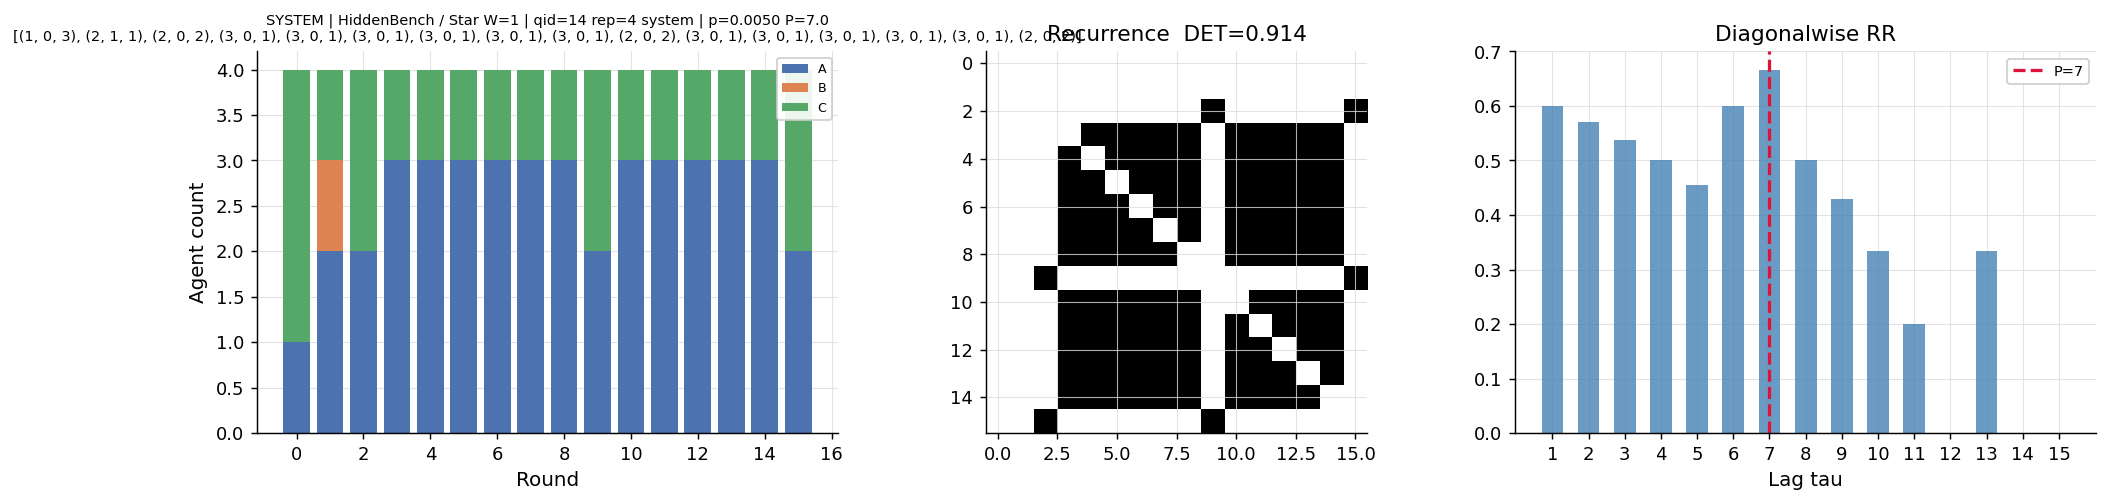

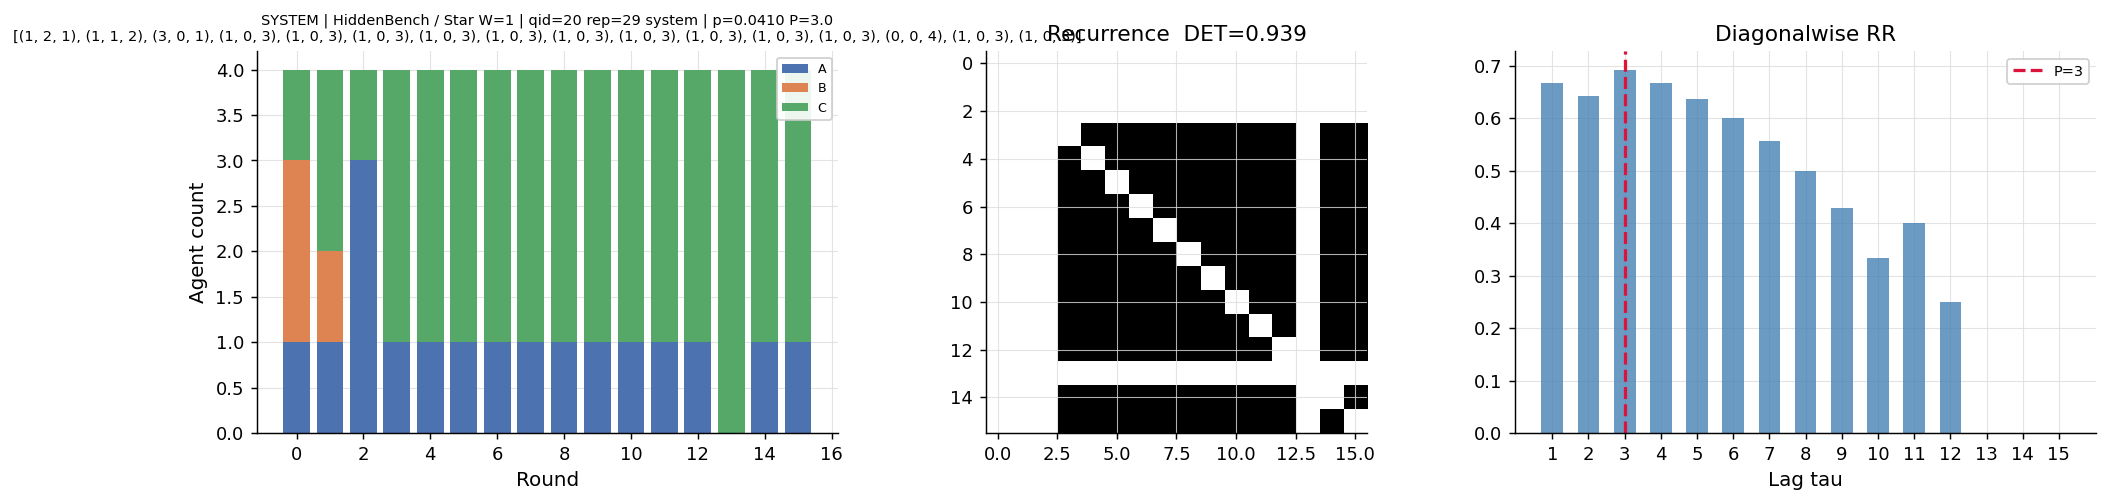

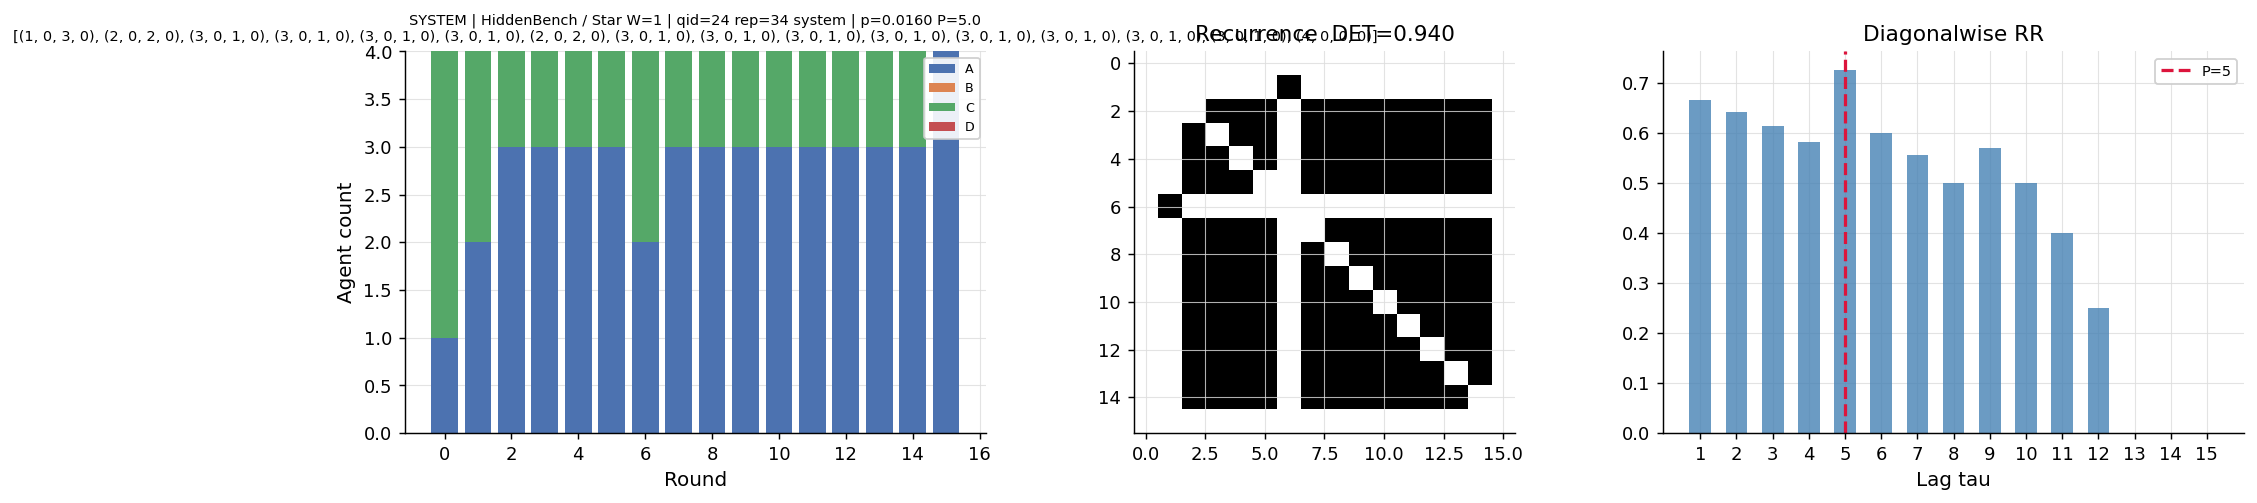

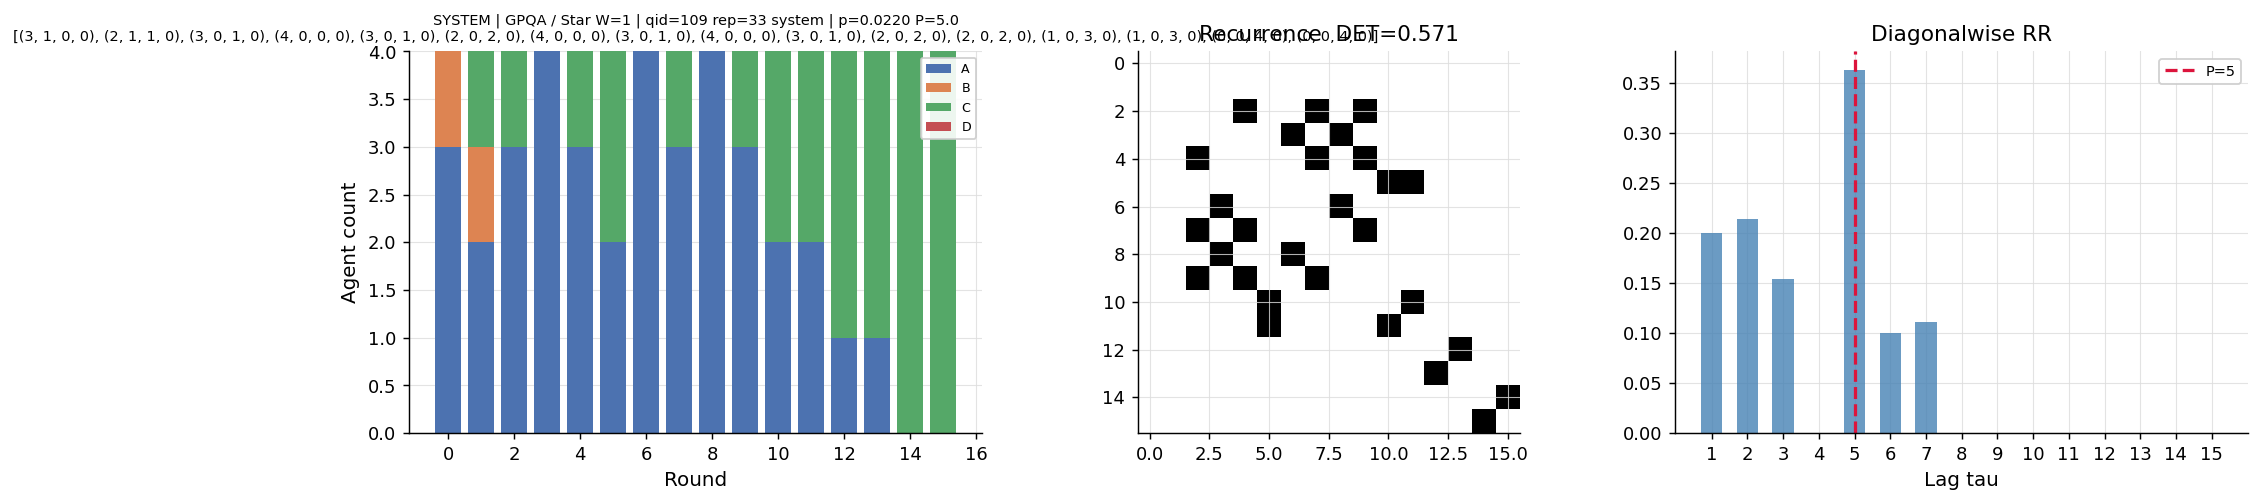

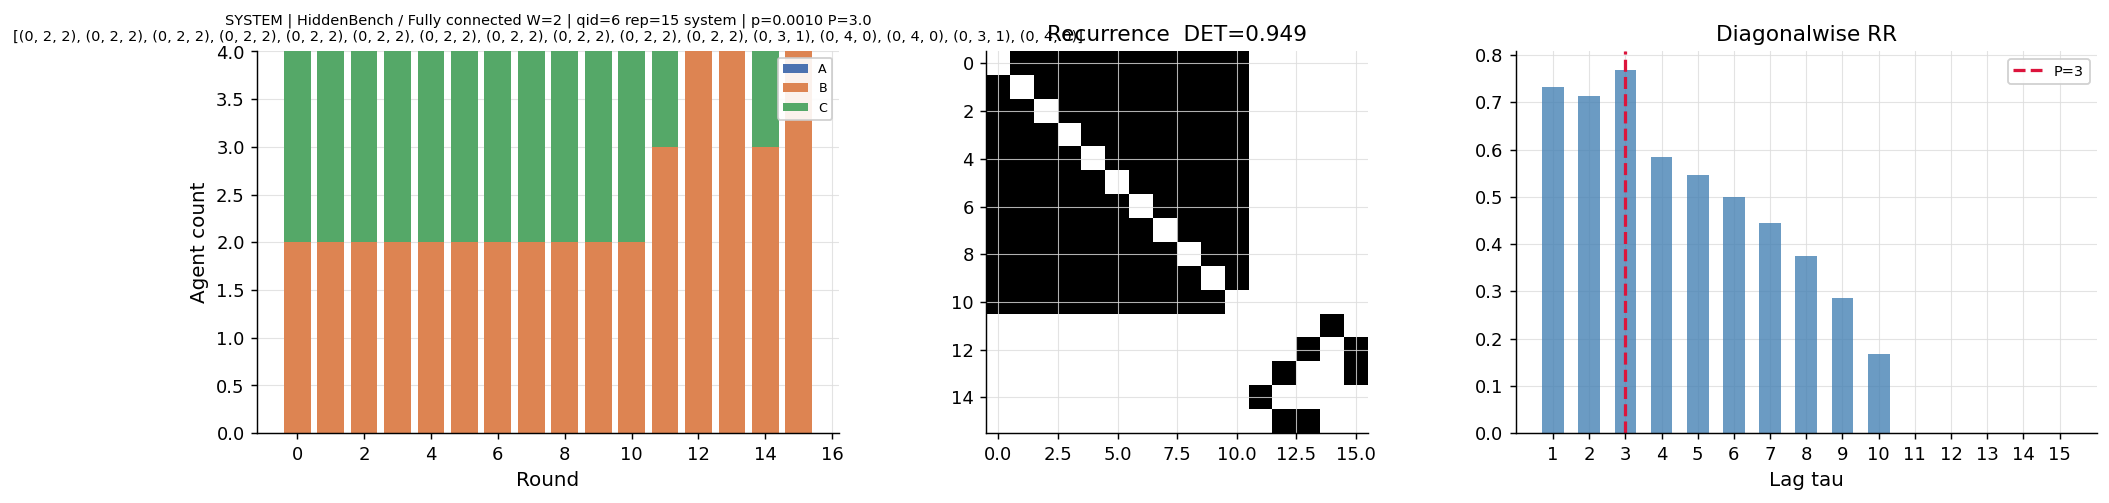

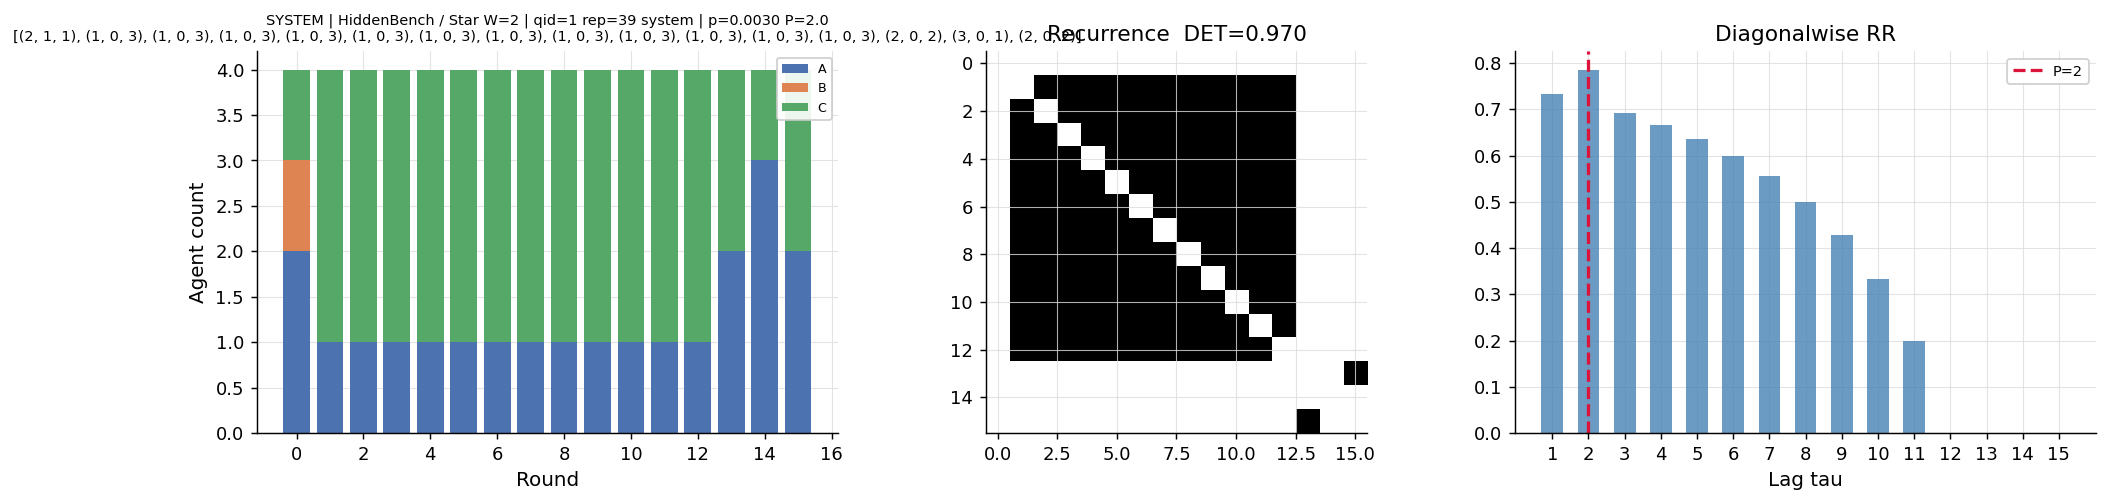

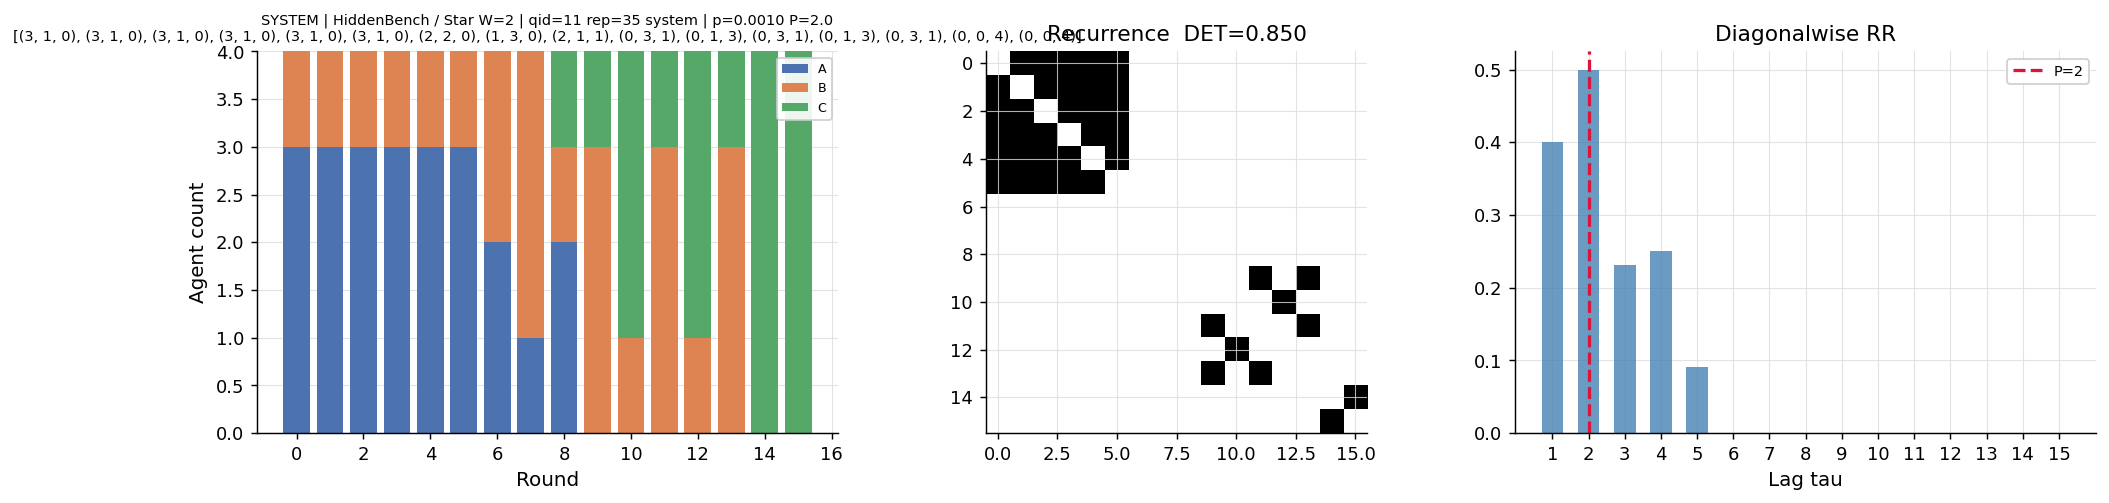

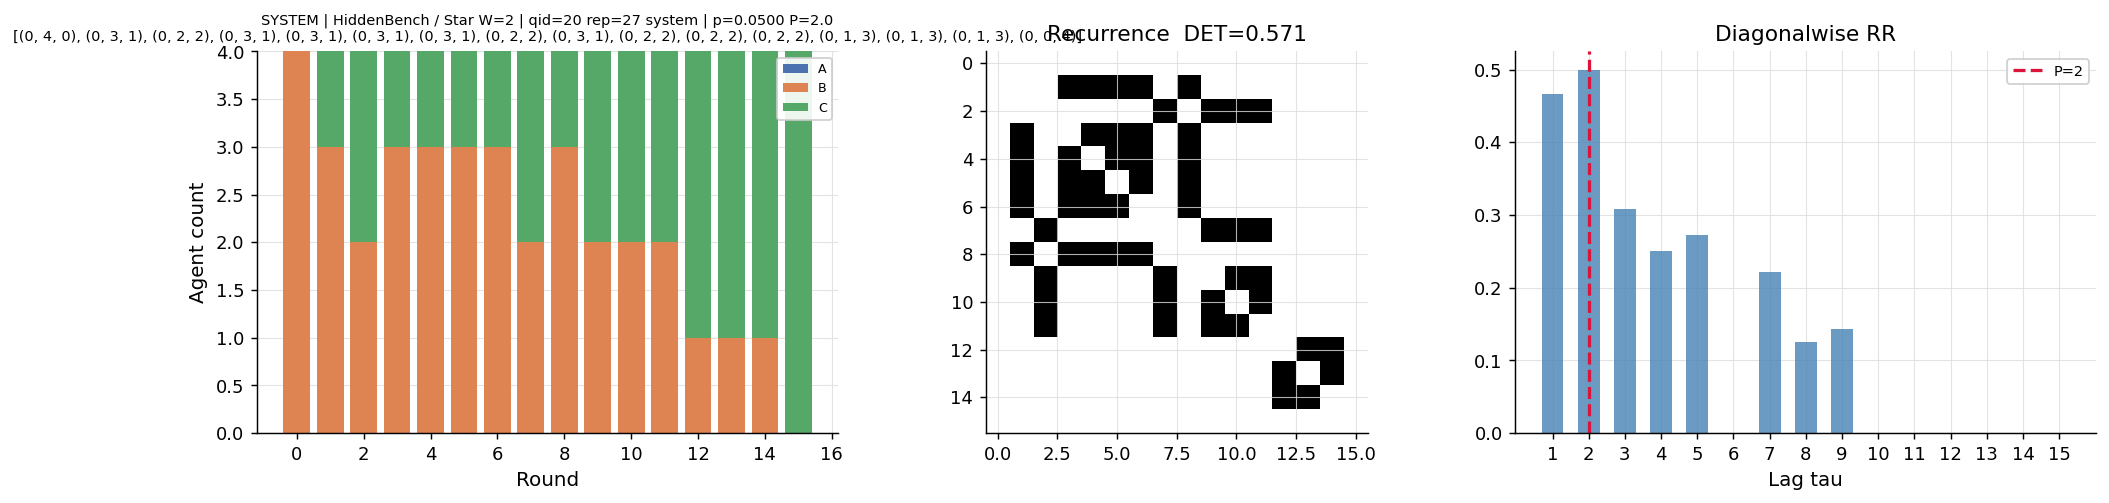

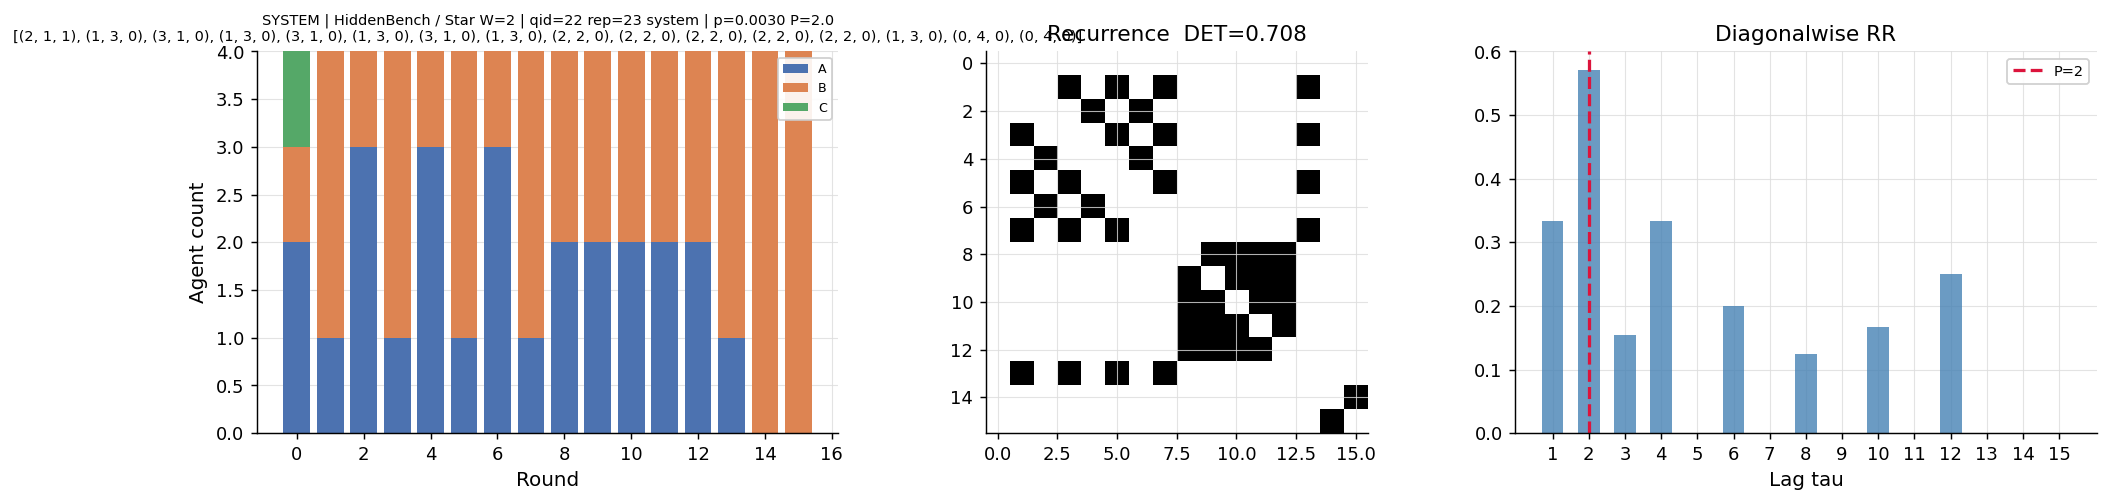

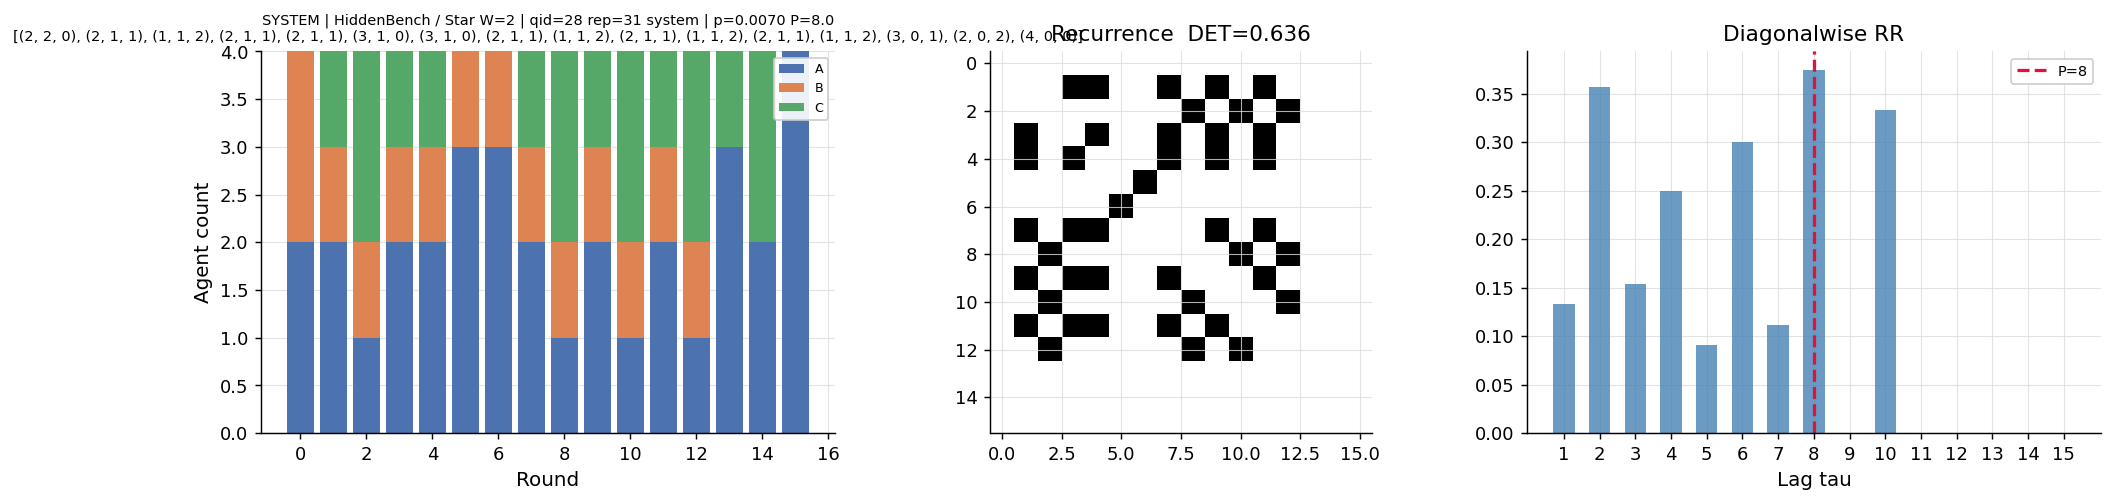

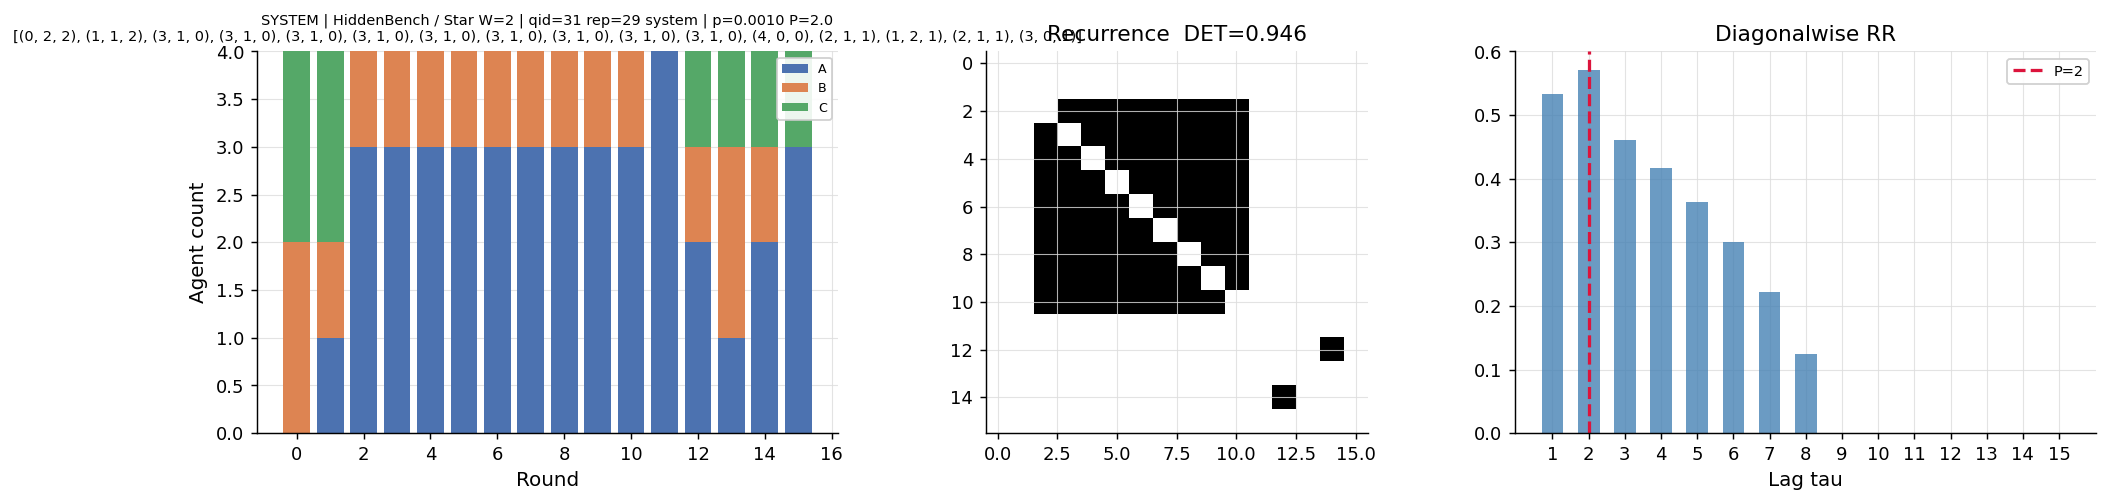

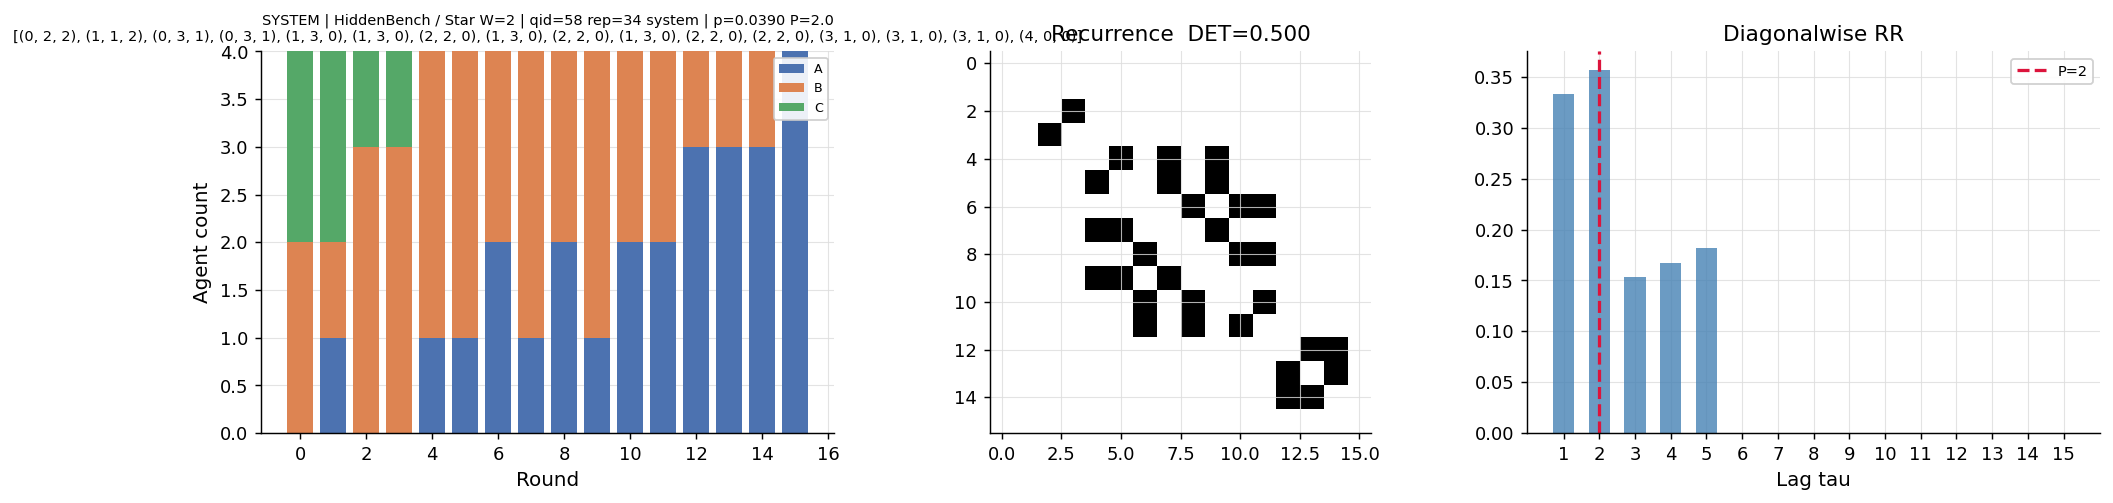

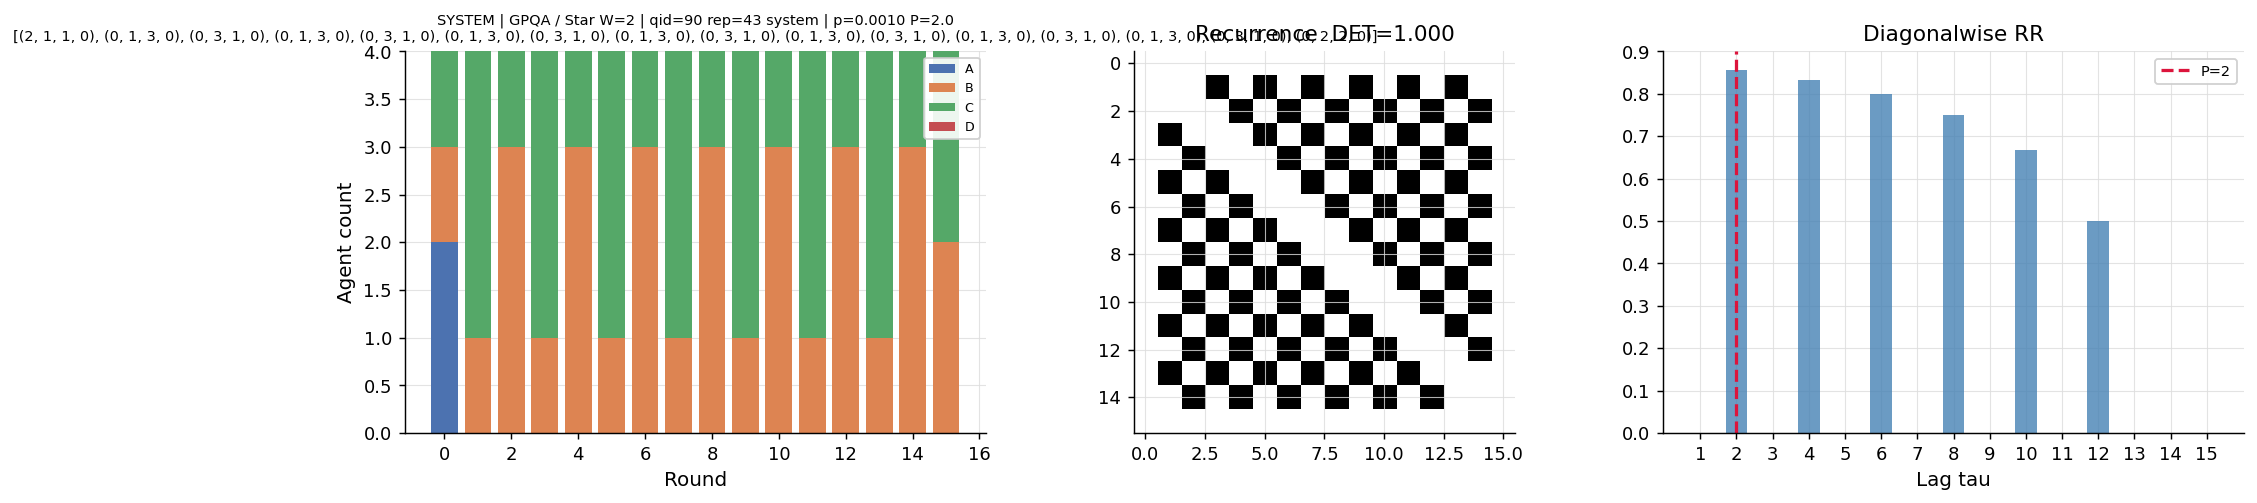

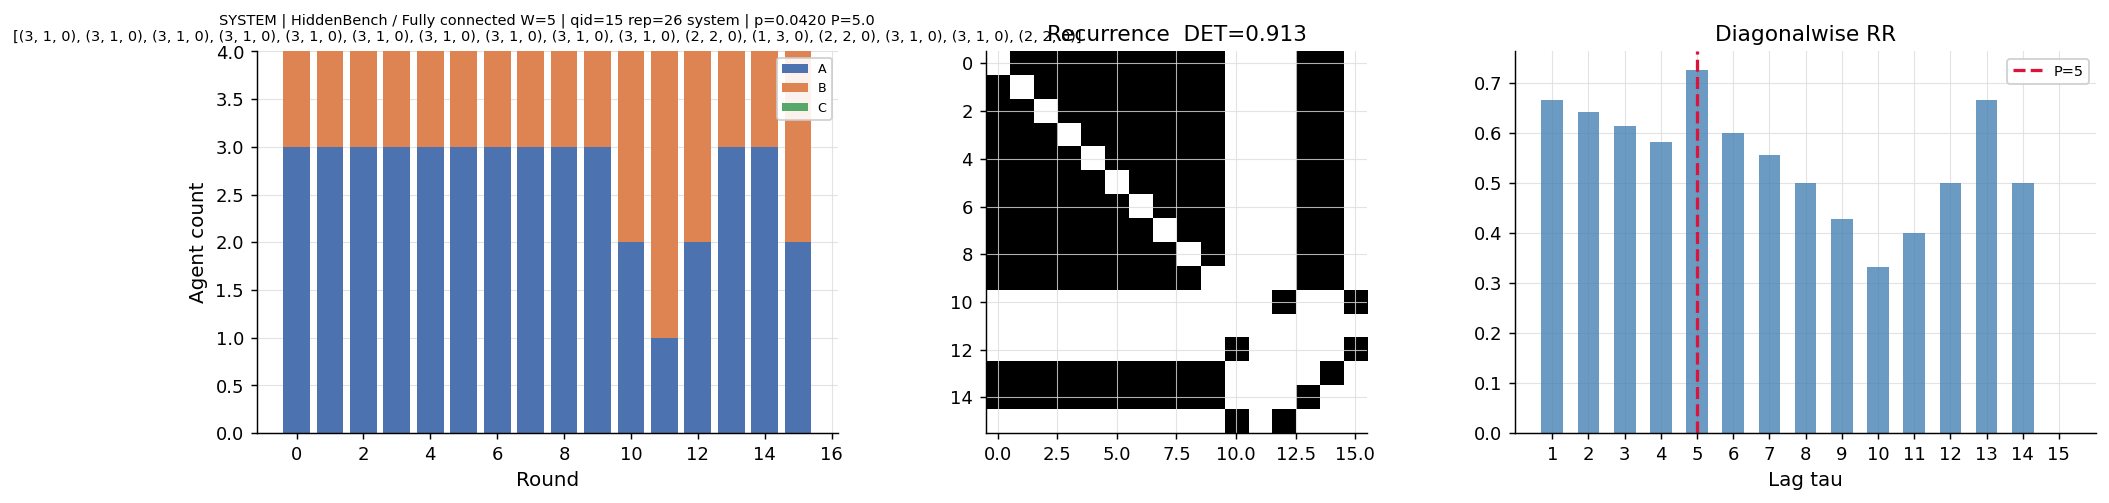

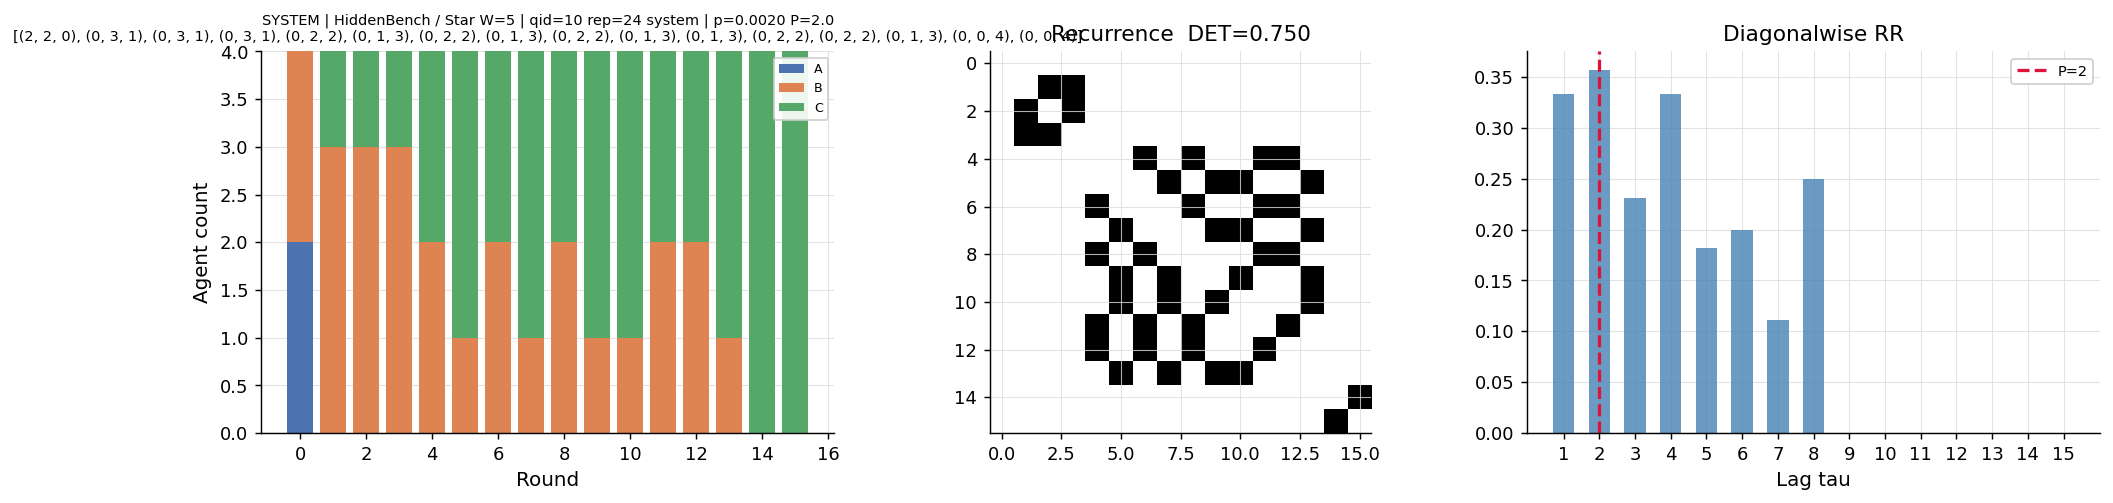

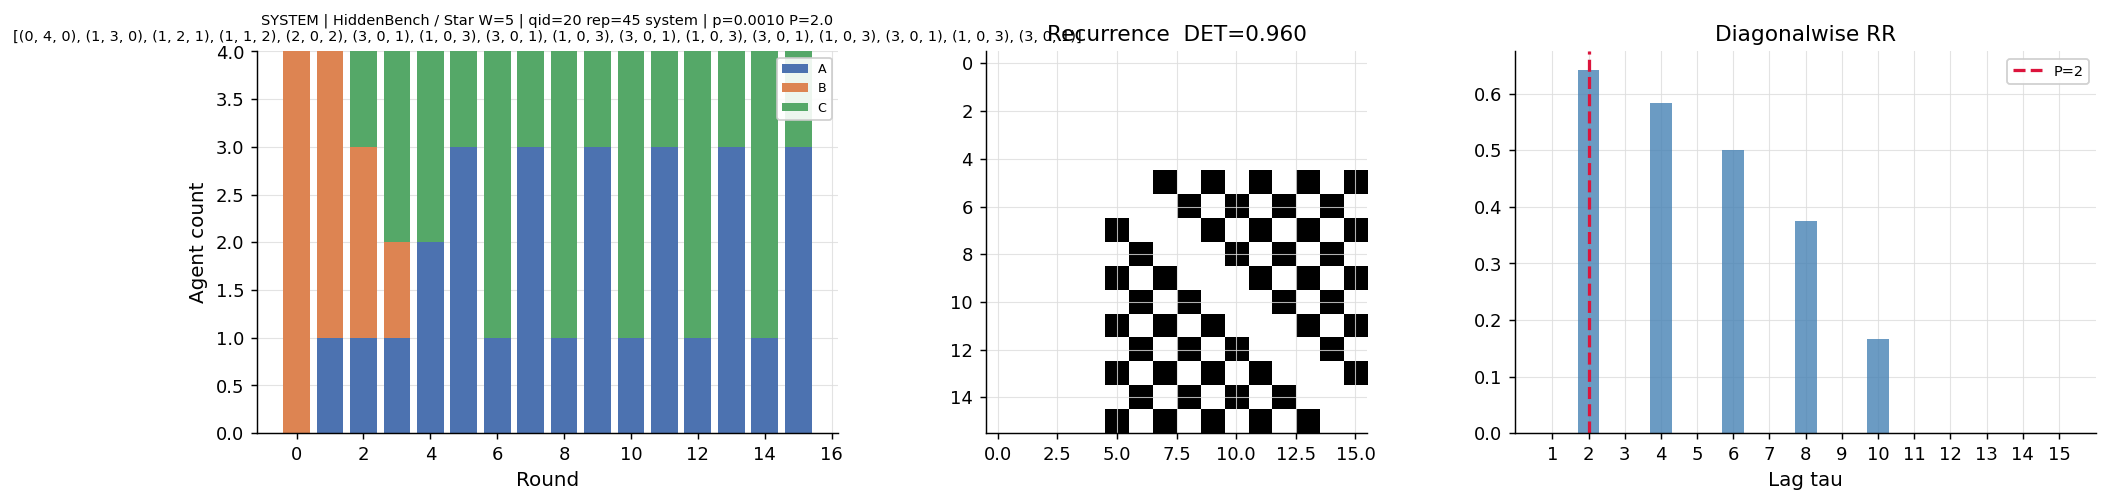

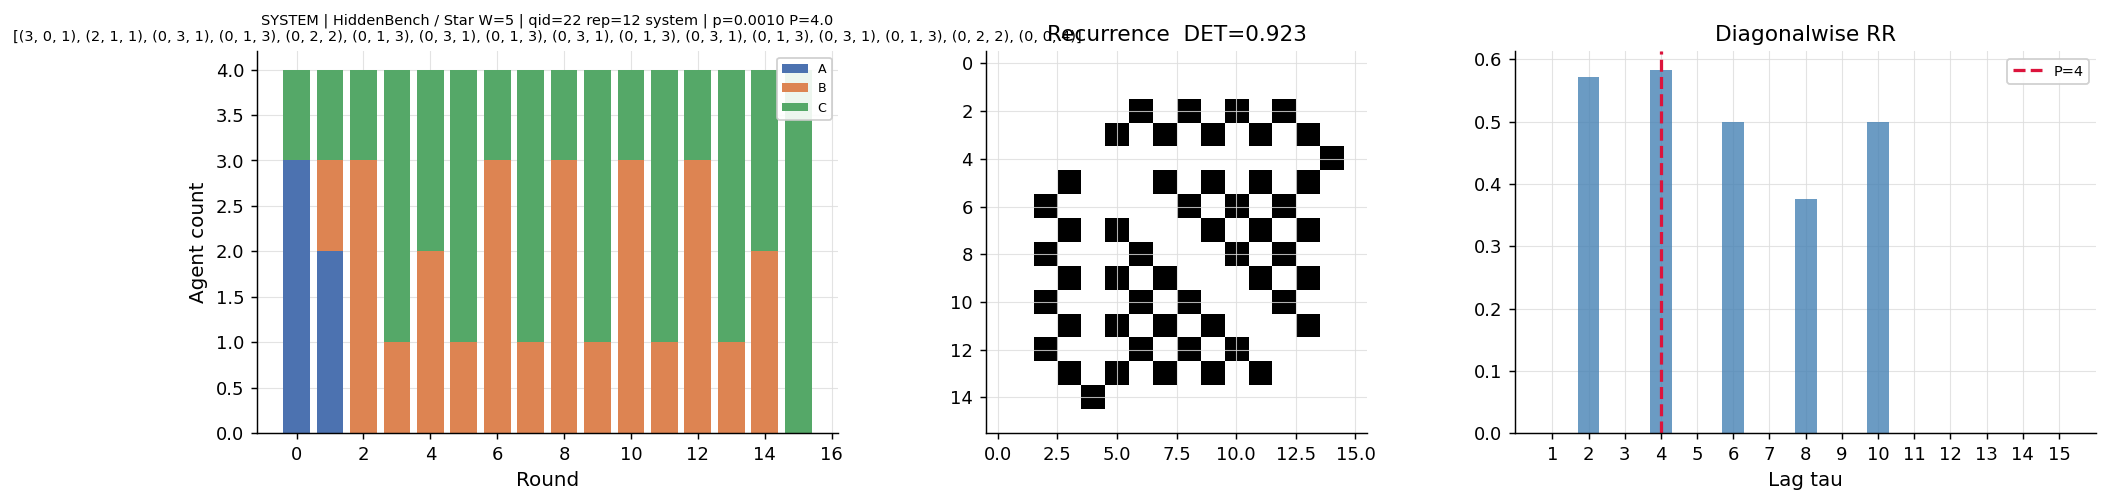

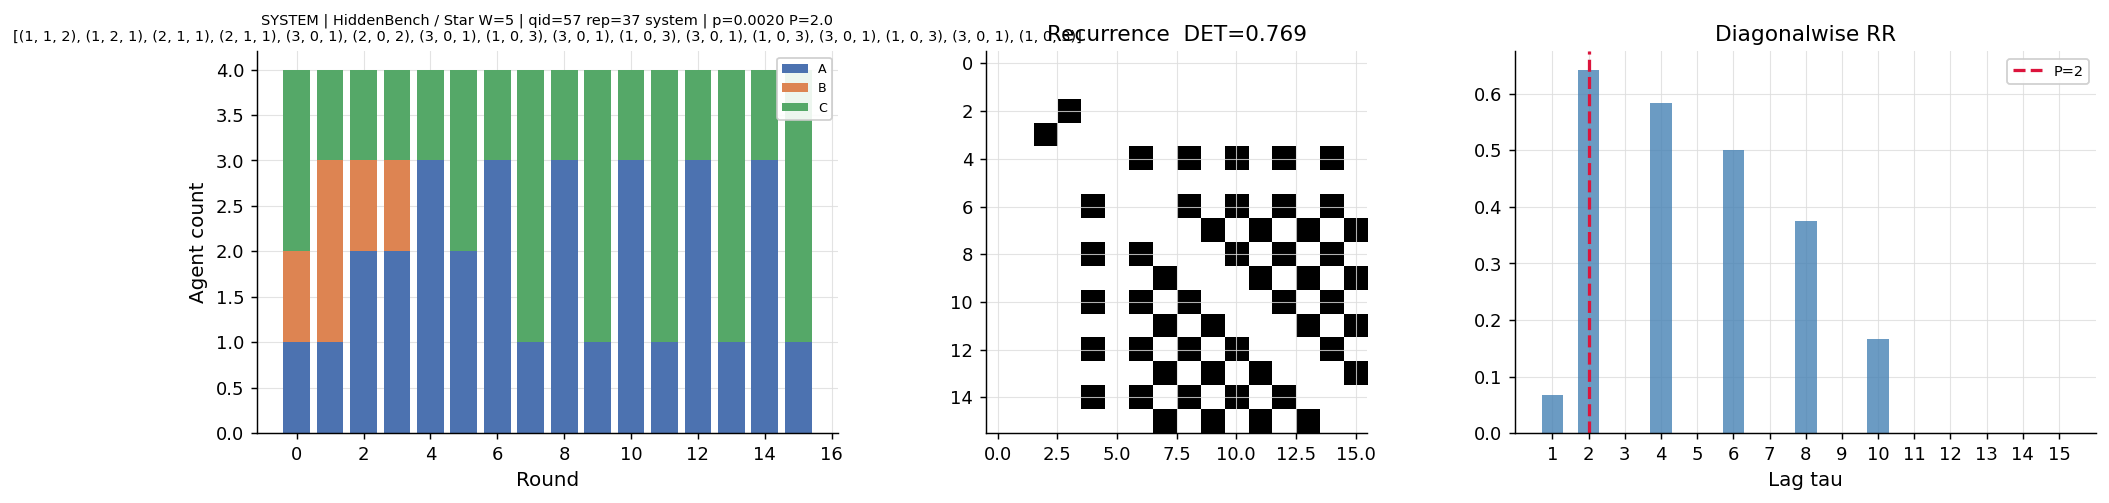

In [11]:
def plot_recurrence(seq, title, ax_seq, ax_rec, ax_rr):
    L = len(seq)
    R = _recurrence_matrix(seq)
    rr = _diagonalwise_rr(R)
    det_val = _det(R)

    vote_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    if isinstance(seq[0], tuple):
        M = len(seq[0]); opts = ['A','B','C','D'][:M]
        bottoms = np.zeros(L)
        colors = ['#4C72B0','#DD8452','#55A868','#c44e52'][:M]
        for i, (opt, col) in enumerate(zip(opts, colors)):
            vals = [s[i] for s in seq]
            ax_seq.bar(range(L), vals, bottom=bottoms, color=col, label=opt, width=0.8)
            bottoms += np.array(vals, dtype=float)
        ax_seq.legend(fontsize=7, loc='upper right')
        ax_seq.set_ylabel('Agent count')
    else:
        cmap = plt.cm.Set1
        codes = [vote_map.get(v, 0) for v in seq]
        ax_seq.bar(range(L), [1]*L, color=[cmap(c/4) for c in codes], width=0.8)
        handles = [mpatches.Patch(color=cmap(i/4), label=v) for i,v in enumerate(['A','B','C','D'])]
        ax_seq.legend(handles=handles, fontsize=7, loc='upper right')
        ax_seq.set_yticks([])
    ax_seq.set_xlabel('Round')
    ax_seq.set_title(f'{title}\n{list(seq) if not isinstance(seq[0],tuple) else seq}', fontsize=8)

    ax_rec.imshow(R.astype(int), cmap='Greys', origin='upper', aspect='equal')
    ax_rec.set_title(f'Recurrence  DET={det_val:.3f}')

    taus = np.arange(1, L)
    ax_rr.bar(taus, rr, color='steelblue', alpha=0.8, width=0.6)
    if len(rr):
        P_hat = int(np.argmax(rr)) + 1
        ax_rr.axvline(P_hat, color='crimson', lw=1.8, linestyle='--', label=f'P={P_hat}')
        ax_rr.legend(fontsize=8)
    ax_rr.set_xlabel('Lag tau'); ax_rr.set_title('Diagonalwise RR'); ax_rr.set_xticks(taus)

for df, label in [(agent_df, 'AGENT'), (sys_df, 'SYSTEM')]:
    fl = df[df['lc']].reset_index(drop=True)
    if len(fl) == 0:
        print(f'{label}: no flagged cases')
        continue
    print(f'{label}-level flagged cases ({len(fl)}):')
    for _, row in fl.iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        level_info = f"agent={row['agent_idx']}" if 'agent_idx' in row else 'system'
        ttl = (f"{label} | {DS_LABELS[row['dataset']]} / {T_LABELS[row['topology']]} "
               f"W={row['W']} | qid={row['qid']} rep={row['rep_idx']} {level_info} "
               f"| p={row['p_value']:.4f} P={row['period']}")
        plot_recurrence(row['seq'], ttl, axes[0], axes[1], axes[2])
        plt.tight_layout()
        plt.show()

---
## Part 9 — Summary and comparison with old dataset

In [12]:
print('=== SUMMARY ===')
for df, label in [(agent_df,'AGENT'),(sys_df,'SYSTEM')]:
    n = len(df); fp = int(df['fixed_point'].sum())
    c = int((~df['fixed_point']&(df['L']>=4)).sum()); fl = int(df['lc'].sum())
    print(f'{label}: total={n:,}  fixed_pts={fp:,} ({100*fp/n:.1f}%)'
          f'  candidates={c}  flagged={fl}'
          + (f'  p_LC={fl/c:.4f}' if c else ''))
print()
print('OLD dataset (R=30, no anti-conformity prompt): 14 agent, 16 system LCs')
print('NEW dataset (R=50, anti-conformity prompt):')
print(f'  agent:  {int(agent_df["lc"].sum())}')
print(f'  system: {int(sys_df["lc"].sum())}')
print()
# Dataset breakdown
for ds in DATASETS:
    a = int(agent_df[(agent_df.dataset==ds)&agent_df.lc].shape[0])
    s = int(sys_df[(sys_df.dataset==ds)&sys_df.lc].shape[0])
    print(f'  {DS_LABELS[ds]:12s}: agent={a}  system={s}')
print()
# Topology breakdown
for topo in TOPOS:
    a = int(agent_df[(agent_df.topology==topo)&agent_df.lc].shape[0])
    s = int(sys_df[(sys_df.topology==topo)&sys_df.lc].shape[0])
    print(f'  {topo:5s}: agent={a}  system={s}')

=== SUMMARY ===
AGENT: total=84,000  fixed_pts=83,529 (99.4%)  candidates=463  flagged=29  p_LC=0.0626
SYSTEM: total=21,000  fixed_pts=20,707 (98.6%)  candidates=291  flagged=23  p_LC=0.0790

OLD dataset (R=30, no anti-conformity prompt): 14 agent, 16 system LCs
NEW dataset (R=50, anti-conformity prompt):
  agent:  29
  system: 23

  GPQA        : agent=5  system=2
  HiddenBench : agent=24  system=21

  fc   : agent=2  system=5
  star : agent=27  system=18
